# 📑 User Guide: Bibliometric Analysis Pipeline (CAPES + OpenAlex)

This notebook analyses the scientific production of Brazilian postgraduate programs. It calculates the **Publishing Performance Index (PPI)**, measures **Thematic Drift** (how an author's research evolves after collaborations), runs **7 Research Questions** with cluster-robust OLS, performs **bidirectional reciprocal-influence** analysis, and generates an **interdisciplinary collaboration** report showing how cross-field co-authorship evolves over time.

---

### 🚀 Quick Start

1. **API Key**: Add your OpenAlex API key to a file called `env.keys` in the project root:
   ```
   OA_API_KEY=your_key_here
   ```
2. **Program ID**: Change `ID_PROGRAMA` in Cell 1 to the CAPES program ID you want to analyse. Find it at [dadosabertos.capes.gov.br](https://dadosabertos.capes.gov.br/).
3. **Local Snapshot**: The notebook uses a local OpenAlex snapshot (`openalex-snapshot/`) for **author ID resolution only**. Works and author-detail data are fetched live from the OpenAlex API via `pyalex`. The one-time DuckDB index build takes ~6–8 min on first run; subsequent runs load instantly.
4. **Run all cells** in order (Kernel → Restart & Run All).

---

### 📂 Output Files

| File | Contents |
|---|---|
| `checkpoints/` | Intermediate CSV/JSON/pickle files — skip re-fetching on re-runs |
| `checkpoints/openalex_local.duckdb` | Persistent DuckDB index of the local author snapshot |
| `export/{ID}/relatorio_{ID}.pdf` | Main report: PPI, drift, RQ1-7 results (two groups) |
| `export/{ID}/relatorio_{ID}_capes.pdf` | Same, restricted to CAPES program researchers |
| `export/{ID}/relatorio_{ID}_bidirecional.pdf` | Reciprocal-influence & Neutron Star analysis |
| `export/{ID}/relatorio_{ID}_cross_field.pdf` | Cross-field / interdisciplinary collaboration evolution |


### 1. Environment Setup

This cell:
- Reads the OpenAlex API key from `env.keys` (never hard-coded)
- Installs dependencies: `statsmodels`, `scipy`, `pandas`, `numpy`, `matplotlib`, `seaborn`, `duckdb`, `pyalex`, `mako`
- Configures **pyalex** globally (polite-pool e-mail, API key, automatic retry on 429/5xx)
- Defines `WORK_SELECT` / `AUTHOR_SELECT` — field-selection strings that tell the API to return only the fields we consume, reducing payload size
- Sets local snapshot paths (`SNAPSHOT_BASE`, `DUCKDB_PATH`) used for the one-time author-index build in Cell 2
- Defines `_normalize_name()` — strips accents, lowercases, and collapses whitespace for fuzzy author-name matching against the snapshot


In [137]:
# Load API key from env.keys file
import os
from pathlib import Path

env_file = Path("env.keys")
oa_api_key = None
ID_programa_capes = "1401" # @param {"type":"string","placeholder":"Digite o ID do programa de pós graduação"}

if env_file.exists():
    with open(env_file) as f:
        for line in f:
            if line.startswith("OA_API_KEY="):
                oa_api_key = line.split("=", 1)[1].strip()
                break

if not oa_api_key:
    raise ValueError("OA_API_KEY not found in env.keys file")

# ── Instalação de Dependências e Configurações Gerais ─────────────────────────
%pip install -q statsmodels>=0.14 scipy>=1.9 pandas>=1.5 numpy>=1.23 matplotlib seaborn duckdb>=1.1 pyopencl pyalex mako ipywidgets pyarrow

import requests
import pandas as pd
import numpy as np
import time
import json
import re
import unicodedata
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from itertools import combinations
from scipy import stats
import statsmodels.formula.api as smf
from urllib3.exceptions import InsecureRequestWarning
import duckdb

# pyalex — used for works and author-details fetching (after DuckDB ID resolution)
import pyalex
from pyalex import Authors, Works

warnings.simplefilter('ignore', InsecureRequestWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# --- CAPES API (unchanged) ---
CAPES_BASE_URL = "https://apigw-proxy.capes.gov.br/observatorio/data/observatorio/producao"
ID_PROGRAMA = ID_programa_capes
CAPES_PAGE_SIZE = 100

# --- pyalex global config ---
pyalex.config.email = "gabrielc.pule@gmail.com"
pyalex.config.api_key = oa_api_key
pyalex.config.max_retries = 5
pyalex.config.retry_backoff_factor = 0.4
pyalex.config.retry_http_codes = [429, 500, 503]

# Fields we actually need from a Work (select= dramatically reduces payload)
WORK_SELECT = (
    "id,display_name,doi,publication_year,cited_by_count,fwci,"
    "authorships,topics"
)

# Fields we actually need from an Author record
AUTHOR_SELECT = (
    "id,display_name,works_count,cited_by_count,summary_stats,topics,affiliations"
)

# --- Local OpenAlex snapshot paths (used for author ID resolution only) ---
SNAPSHOT_BASE = Path("openalex-snapshot/data")
DUCKDB_PATH   = Path("checkpoints/openalex_local.duckdb")
DUCKDB_TEMP   = Path("checkpoints/duckdb_tmp")
DUCKDB_TEMP.mkdir(parents=True, exist_ok=True)

# --- Name normalisation helper for author resolution ---
def _normalize_name(s: str) -> str:
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    s = re.sub(r"[^a-z0-9 ]", " ", s.lower())
    return re.sub(r"\s+", " ", s).strip()

print("✅ Dependências prontas e ambiente configurado.")


Note: you may need to restart the kernel to use updated packages.
✅ Dependências prontas e ambiente configurado.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2. Data Extraction & Author ID Resolution

**Step A — DuckDB one-time index build** (runs only if the tables don't already exist):

| Table | Source | Purpose |
|---|---|---|
| `author_names` | `openalex-snapshot/data/authors/` | Maps display name / name alternatives → OpenAlex author ID |
| `author_details` | same | Stores h-index, i10-index, affiliations, full topic hierarchy per author |

Both scans cover ~113 M author records in a single pass (~6–8 min); subsequent runs are instant.

**Step B — CAPES download**: All production records for `ID_PROGRAMA` are fetched from the CAPES Open Data API and cached as `checkpoints/capes_{ID}.json`.

**Step C — Author name → OpenAlex ID resolution** (DuckDB, no API calls):
1. Exact normalized match on `display_name`
2. Search inside `display_name_alternatives` array
3. Surname-first transposition fallback (e.g., `"CARDOSO, PEDRO A."` → `"PEDRO A. CARDOSO"`)

Results cached in `checkpoints/filtered_authors_{ID}.csv`.


In [138]:
# ── Extração de Dados da CAPES e Resolução de Autores (DuckDB local) ─────────
import pickle
from pathlib import Path

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

# ── DuckDB connection (persistent, shared across all subsequent cells) ────────
con = duckdb.connect(str(DUCKDB_PATH))
con.execute("SET threads = 12")
con.execute("SET memory_limit = '10GB'")
con.execute(f"SET temp_directory = '{DUCKDB_TEMP.as_posix()}'")
con.execute("SET enable_progress_bar = true")

_EXISTING_TABLES = set(con.execute("SHOW TABLES").fetchdf()["name"].tolist())

# ── One-time build: author_names (name → OpenAlex ID index) ──────────────────
if "author_names" not in _EXISTING_TABLES:
    print("⌛ Construindo tabela author_names (~6–8 min, uma única vez)…")
    con.execute("""
        CREATE TABLE author_names AS
        SELECT id AS author_id, display_name, display_name_alternatives AS name_alternatives
        FROM read_ndjson(
            'openalex-snapshot/data/authors/*/part_*.gz',
            columns = {
                'id':                        'VARCHAR',
                'display_name':              'VARCHAR',
                'display_name_alternatives': 'VARCHAR[]'
            },
            format = 'newline_delimited', compression = 'gzip', ignore_errors = true)
    """)
    con.execute("CREATE INDEX idx_author_names_display ON author_names (display_name)")
    print(f"✅ author_names pronta: {con.execute('SELECT COUNT(*) FROM author_names').fetchone()[0]:,} registros")

# ── One-time build: author_details (full author profiles) ────────────────────
if "author_details" not in _EXISTING_TABLES:
    print("⌛ Construindo tabela author_details (~6–8 min, uma única vez)…")
    con.execute("""
        CREATE TABLE author_details AS
        SELECT
            id                      AS author_id,
            display_name,
            works_count,
            cited_by_count,
            summary_stats.h_index   AS h_index,
            summary_stats.i10_index AS i10_index,
            topics[1].display_name  AS topic_display_name_1,
            last_known_institutions[1].id           AS last_known_institution_id,
            last_known_institutions[1].display_name AS last_known_institution_name,
            affiliations
        FROM read_ndjson(
            'openalex-snapshot/data/authors/*/part_*.gz',
            columns = {
                'id':            'VARCHAR',
                'display_name':  'VARCHAR',
                'works_count':   'INTEGER',
                'cited_by_count':'INTEGER',
                'summary_stats': 'STRUCT(h_index INTEGER, i10_index INTEGER)',
                'topics':        'STRUCT(id VARCHAR, display_name VARCHAR, score DOUBLE)[]',
                'last_known_institutions': 'STRUCT(id VARCHAR, display_name VARCHAR, country_code VARCHAR, type VARCHAR)[]',
                'affiliations':  'STRUCT(institution STRUCT(id VARCHAR, display_name VARCHAR, country_code VARCHAR, type VARCHAR), years INTEGER[])[]'
            },
            format = 'newline_delimited', compression = 'gzip', ignore_errors = true)
    """)
    con.execute("CREATE INDEX idx_author_details_id ON author_details (author_id)")
    print(f"✅ author_details pronta: {con.execute('SELECT COUNT(*) FROM author_details').fetchone()[0]:,} registros")

# ── One-time build: author_name_alts_flat (pre-normalized alternatives) ──────
if "author_name_alts_flat" not in _EXISTING_TABLES:
    print("⌛ Construindo tabela author_name_alts_flat (~10–15 min, uma única vez)…")
    con.execute("""
        CREATE TABLE author_name_alts_flat AS
        SELECT author_id,
               lower(regexp_replace(alt, '[^a-zA-Z0-9 ]', ' ', 'g')) AS norm_alt
        FROM (
            SELECT author_id, UNNEST(name_alternatives) AS alt
            FROM author_names
        )
        WHERE alt IS NOT NULL AND trim(alt) <> ''
    """)
    con.execute("CREATE INDEX idx_author_name_alts_norm ON author_name_alts_flat (norm_alt)")
    print(f"✅ author_name_alts_flat pronta: "
          f"{con.execute('SELECT COUNT(*) FROM author_name_alts_flat').fetchone()[0]:,} entradas")

# ── CAPES data download ───────────────────────────────────────────────────────
def baixar_dados_producao(id_programa):
    print(f"Verificando id-programa da CAPES: {id_programa}...")
    try:
        url_teste = f"{CAPES_BASE_URL}?query=id-programa:({id_programa})&page=0&size=1"
        response = requests.get(url_teste, verify=False)
        if not response.json().get('content', response.json()):
            return None
    except Exception as e:
        print(f"Erro CAPES: {e}")
        return None

    todos_registros = []
    page = 0
    while True:
        url_paginada = f"{CAPES_BASE_URL}?query=id-programa:({id_programa})&page={page}&size={CAPES_PAGE_SIZE}"
        try:
            resp = requests.get(url_paginada, verify=False)
            if resp.status_code != 200: break
            registros_pagina = resp.json().get('content', resp.json())
            if not registros_pagina: break
            todos_registros.extend(registros_pagina)
            if len(registros_pagina) < CAPES_PAGE_SIZE: break
            page += 1
            time.sleep(0.2)
        except Exception:
            break

    if todos_registros:
        df = pd.json_normalize(todos_registros)
        print(f"Download concluido! Producoes CAPES encontradas: {len(todos_registros)}")
        return df
    return None

# --- CAPES checkpoint (JSON para compatibilidade entre versões de pandas) ---
CKPT_CAPES     = CHECKPOINT_DIR / f"capes_{ID_PROGRAMA}.json"
CKPT_CAPES_OLD = CHECKPOINT_DIR / f"capes_{ID_PROGRAMA}.pkl"

def _load_capes():
    if CKPT_CAPES.exists():
        df = pd.read_json(CKPT_CAPES, orient="records")
        print(f"✅ CAPES checkpoint carregado: {len(df)} producoes")
        return df
    if CKPT_CAPES_OLD.exists():
        try:
            import pickle
            with open(CKPT_CAPES_OLD, "rb") as _f:
                df = pickle.load(_f)
            print(f"✅ CAPES pickle carregado: {len(df)} producoes (migrando para JSON…)")
            df.to_json(CKPT_CAPES, orient="records", force_ascii=False)
            return df
        except Exception as e:
            print(f"⚠️  Pickle corrompido/incompatível ({e}). Re-baixando da CAPES…")
    df = baixar_dados_producao(ID_PROGRAMA)
    df.to_json(CKPT_CAPES, orient="records", force_ascii=False)
    print(f"Checkpoint CAPES salvo: {CKPT_CAPES}")
    return df

df_resultado = _load_capes()
NOME_PROGRAMA = (df_resultado["nomePrograma"].dropna().iloc[0].strip()
                 if "nomePrograma" in df_resultado.columns and
                    df_resultado["nomePrograma"].notna().any() else "")
print(f"Programa: {NOME_PROGRAMA}")
NOME_FACULDADE = (df_resultado["siglaIes"].dropna().iloc[0].strip()
                  if "siglaIes" in df_resultado.columns and
                     df_resultado["siglaIes"].notna().any() else "")
print(f"Faculdade: {NOME_FACULDADE}")

# Extrair autores únicos (sempre derivado de df_resultado)
df_autores_exploded = df_resultado.explode('autores')
df_autores_norm = pd.json_normalize(df_autores_exploded['autores'].dropna())
pesquisadores_unicos = df_autores_norm['nomePessoa'].unique()
df_pesquisadores = (pd.DataFrame(pesquisadores_unicos, columns=['nomePessoa'])
                    .sort_values('nomePessoa').reset_index(drop=True))
print(f"Pesquisadores unicos CAPES encontrados: {len(df_pesquisadores)}")

# ── Author name → OpenAlex ID resolution (DuckDB) ────────────────────────────
CKPT_FILTERED_AUTHORS = CHECKPOINT_DIR / f"filtered_authors_{ID_PROGRAMA}.csv"
if CKPT_FILTERED_AUTHORS.exists():
    df_filtered_authors = pd.read_csv(CKPT_FILTERED_AUTHORS)
    before = len(df_filtered_authors)
    df_filtered_authors = (df_filtered_authors
                           .drop_duplicates(subset=['open_alex_id'])
                           .reset_index(drop=True))
    if before > len(df_filtered_authors):
        print(f"  {before - len(df_filtered_authors)} IDs duplicados removidos do checkpoint")
    print(f"✅ Author ID checkpoint carregado: {len(df_filtered_authors)} IDs validos")
else:
    names = df_pesquisadores['nomePessoa'].tolist()
    total = len(names)

    def _resolve_duckdb(name: str):
        norm = _normalize_name(name)
        # Step 1: exact normalized match on display_name
        row = con.execute("""
            SELECT author_id FROM author_names
            WHERE lower(regexp_replace(display_name, '[^a-zA-Z0-9 ]', ' ', 'g')) = ?
            LIMIT 1
        """, [norm]).fetchone()
        if row:
            return row[0]
        # Step 2: indexed lookup in pre-normalized alternatives table
        row = con.execute("""
            SELECT author_id FROM author_name_alts_flat
            WHERE norm_alt = ?
            LIMIT 1
        """, [norm]).fetchone()
        if row:
            return row[0]
        # Step 3: surname-first transposition (e.g. "CARDOSO, PEDRO A." → "PEDRO A. CARDOSO")
        if ',' in name:
            parts = name.split(',', 1)
            transposed = _normalize_name(f"{parts[1].strip()} {parts[0].strip()}")
            row = con.execute("""
                SELECT author_id FROM author_names
                WHERE lower(regexp_replace(display_name, '[^a-zA-Z0-9 ]', ' ', 'g')) = ?
                LIMIT 1
            """, [transposed]).fetchone()
            if row:
                return row[0]
        return None

    print(f"Iniciando resolução de {total} autores no OpenAlex via DuckDB…")
    ids_map = {}
    for i, name in enumerate(names, 1):
        ids_map[name] = _resolve_duckdb(name)
        if i % 50 == 0 or i == total:
            found = sum(1 for v in ids_map.values() if v is not None)
            print(f"  {i}/{total} processados — {found} IDs encontrados ate agora")

    ids = [ids_map[n] for n in names]
    df_pesquisadores['open_alex_id'] = ids
    df_filtered_authors = (df_pesquisadores
                           .dropna(subset=['open_alex_id'])
                           .drop_duplicates(subset=['open_alex_id'])
                           .reset_index(drop=True))
    df_filtered_authors.to_csv(CKPT_FILTERED_AUTHORS, index=False)
    print(f"Checkpoint de IDs salvo: {CKPT_FILTERED_AUTHORS}")

print(f"✅ Encontrados {len(df_filtered_authors)} IDs validos do OpenAlex.")


✅ CAPES checkpoint carregado: 2600 producoes
Programa: Arquitetura e Urbanismo
Faculdade: PUCCAMP
Pesquisadores unicos CAPES encontrados: 581
✅ Author ID checkpoint carregado: 288 IDs validos
✅ Encontrados 288 IDs validos do OpenAlex.


### 3. Works Retrieval & Author Details

Uses **pyalex** (live OpenAlex API) for two fetches:

**Works** — batches of 50 author IDs per request, cursor-paginated at `per_page=200`, filtered to `has_doi=True`, `is_retracted=False`, `publication_year>1990`. Returns `df_works` (one row per unique work) and `df_rels` (one row per work × author, with top-3 topics and institution).

**Author details** — batches of 50 OpenAlex IDs per request, `select=AUTHOR_SELECT`. Stores per author:
- Bibliometric metrics: `works_count`, `cited_by_count`, `h_index`, `i10_index`
- Most recent affiliation: institution, year
- **`author_topics_json`** — full 4-level topic hierarchy (topic → subfield → field → domain) with scores, used by the cross-field collaboration report

Both fetches are checkpoint-guarded: stale or missing checkpoints trigger a re-fetch automatically.


In [139]:
# ── Busca Compreensiva de Obras e Detalhamento de Autores (pyalex) ────────────
CKPT_WORKS          = CHECKPOINT_DIR / f"works_{ID_PROGRAMA}.csv"
CKPT_RELS           = CHECKPOINT_DIR / f"rels_{ID_PROGRAMA}.csv"
CKPT_AUTHOR_DETAILS = CHECKPOINT_DIR / f"author_details_{ID_PROGRAMA}.csv"

# Schemas — used to invalidate stale checkpoints when columns change
_RELS_REQUIRED_COLS    = {"institution_id", "institution_display_name"}
_AUTHORS_REQUIRED_COLS = {"last_institution_id", "last_institution_display_name",
                          "last_affiliation_year", "affiliations_json", "i10_index",
                          "author_topics_json"}

# --- Works + Relations checkpoint ---
_rels_stale = (CKPT_RELS.exists()
               and bool(_RELS_REQUIRED_COLS - set(pd.read_csv(CKPT_RELS, nrows=0).columns)))
if _rels_stale:
    print("⚠️  Checkpoint de relações desatualizado (faltam colunas de instituição). Refazendo fetch…")

if CKPT_WORKS.exists() and CKPT_RELS.exists() and not _rels_stale:
    df_works = pd.read_csv(CKPT_WORKS)
    df_rels  = pd.read_csv(CKPT_RELS)
    df_rels  = df_rels.dropna(subset=["work_id", "publication_year"])
    df_rels["publication_year"] = df_rels["publication_year"].astype(int)
    print(f"✅ Works checkpoint carregado: {len(df_works)} obras, {len(df_rels)} relações")
else:
    author_ids_clean = [url.split('/')[-1] for url in df_filtered_authors['open_alex_id']]
    all_works_data = []
    AUTHOR_BATCH = 50

    print("⌛ Buscando obras detalhadas no OpenAlex via pyalex (cursor, per_page=200)…")
    for i in range(0, len(author_ids_clean), AUTHOR_BATCH):
        batch = author_ids_clean[i:i + AUTHOR_BATCH]
        author_filter = "|".join(batch)
        for page in (Works()
                     .filter(author={"id": author_filter},
                             has_doi=True,
                             is_retracted=False,
                             publication_year=">1990")
                     .select(WORK_SELECT)
                     .paginate(method="cursor", per_page=200)):
            all_works_data.extend(page)

    unique_works_dict = {w['id']: w for w in all_works_data}
    all_unique_works  = list(unique_works_dict.values())
    print(f"✅ Total de obras únicas recuperadas: {len(all_unique_works)}")

    enhanced_works_rows, author_mapping_rows = [], []
    for work in all_unique_works:
        work_id    = work.get('id', '')
        work_title = work.get('display_name', '')
        doi_full   = work.get('doi', '')

        authorships      = work.get('authorships', [])
        author_ids_str   = "|".join([str(a['author']['id'])
                                     for a in authorships if 'author' in a and a['author'].get('id')])
        author_names_str = "|".join([str(a['author']['display_name'])
                                     for a in authorships if 'author' in a and a['author'].get('display_name')])

        enhanced_works_rows.append({
            'id': work_id, 'display_name': work_title, 'doi': doi_full,
            'publication_year': work.get('publication_year'),
            'cited_by_count':   work.get('cited_by_count'),
            'fwci':             work.get('fwci'),
            'authors_ids':      author_ids_str,
            'authors_names':    author_names_str,
        })

        topics = work.get('topics', [])
        t1 = topics[0] if len(topics) > 0 else {}
        t2 = topics[1] if len(topics) > 1 else {}
        t3 = topics[2] if len(topics) > 2 else {}

        for auth in authorships:
            author_info  = auth.get('author', {})
            insts        = auth.get('institutions') or []
            primary_inst = insts[0] if insts else {}

            author_mapping_rows.append({
                'work_id':                  work_id,
                'work_title':               work_title,
                'author_id':                author_info.get('id'),
                'author_name':              author_info.get('display_name'),
                'author_position':          auth.get('author_position'),
                'author_orcid':             author_info.get('orcid'),
                'institution_id':           primary_inst.get('id'),
                'institution_display_name': primary_inst.get('display_name'),
                'publication_year':         work.get('publication_year'),
                'fwci':                     work.get('fwci'),
                'topic_display_name_1':     t1.get('display_name'),
                'topic_score_1':            t1.get('score'),
                'topic_display_name_2':     t2.get('display_name'),
                'topic_score_2':            t2.get('score'),
                'topic_display_name_3':     t3.get('display_name'),
                'topic_score_3':            t3.get('score'),
                'cited_by_count':           work.get('cited_by_count'),
            })

    df_works = pd.DataFrame(enhanced_works_rows)
    df_rels  = pd.DataFrame(author_mapping_rows)
    df_rels  = df_rels.dropna(subset=["work_id", "publication_year"])
    df_rels["publication_year"] = df_rels["publication_year"].astype(int)

    df_works.to_csv(CKPT_WORKS, index=False)
    df_rels.to_csv(CKPT_RELS,  index=False)
    print("💾 Checkpoints de obras e relações salvos")

# Marcar autores que pertencem ao programa CAPES
programa_ids = set(df_filtered_authors['open_alex_id'].dropna())
df_rels['is_programa']  = df_rels['author_id'].isin(programa_ids)
df_works['has_programa_author'] = df_works['authors_ids'].fillna('').apply(
    lambda s: any(aid in programa_ids for aid in s.split('|') if aid)
)
print(f"   └─ {df_rels['is_programa'].sum()} relações de autores do programa "
      f"({df_rels['author_id'].isin(programa_ids).sum()} de {len(df_rels)} totais)")

# --- Author details checkpoint ---
_authors_stale = (CKPT_AUTHOR_DETAILS.exists()
                  and bool(_AUTHORS_REQUIRED_COLS - set(pd.read_csv(CKPT_AUTHOR_DETAILS, nrows=0).columns)))
if _authors_stale:
    print("⚠️  Checkpoint de autores desatualizado (faltam colunas de afiliação). Refazendo fetch…")

if CKPT_AUTHOR_DETAILS.exists() and not _authors_stale:
    df_authors = pd.read_csv(CKPT_AUTHOR_DETAILS)
    print(f"✅ Author details checkpoint carregado: {len(df_authors)} autores")
else:
    print("⌛ Buscando info detalhada para co-autores via pyalex…")
    all_unique_author_ids = [aid.split('/')[-1]
                             for aid in df_rels['author_id'].dropna().unique()]
    comprehensive_authors = []
    AUTHOR_DETAIL_BATCH = 50

    for i in range(0, len(all_unique_author_ids), AUTHOR_DETAIL_BATCH):
        batch = all_unique_author_ids[i:i + AUTHOR_DETAIL_BATCH]
        try:
            results = (Authors()
                       .filter(openalex="|".join(batch))
                       .select(AUTHOR_SELECT)
                       .get(per_page=AUTHOR_DETAIL_BATCH))
            for author in results:
                topics       = author.get('topics', [])
                affiliations = author.get('affiliations') or []

                aff_flat = [{
                    'institution_id':   (a.get('institution') or {}).get('id'),
                    'institution_name': (a.get('institution') or {}).get('display_name'),
                    'years':            a.get('years') or [],
                } for a in affiliations]

                last_inst, last_year = {}, None
                if aff_flat:
                    ranked = sorted([a for a in aff_flat if a['years']],
                                    key=lambda a: max(a['years']), reverse=True)
                    if ranked:
                        last_inst = {'id':           ranked[0]['institution_id'],
                                     'display_name': ranked[0]['institution_name']}
                        last_year = max(ranked[0]['years'])

                comprehensive_authors.append({
                    'author_id':                     author.get('id'),
                    'display_name':                  author.get('display_name'),
                    'works_count':                   author.get('works_count'),
                    'cited_by_count':                author.get('cited_by_count'),
                    'h_index':                       (author.get('summary_stats') or {}).get('h_index'),
                    'i10_index':                     (author.get('summary_stats') or {}).get('i10_index'),
                    'topic_display_name_1':          topics[0]['display_name'] if topics else None,
                    'author_topics_json':             json.dumps([{
                        'display_name': t.get('display_name'),
                        'subfield':     (t.get('subfield') or {}).get('display_name'),
                        'field':        (t.get('field')    or {}).get('display_name'),
                        'domain':       (t.get('domain')   or {}).get('display_name'),
                        'score':        t.get('score'),
                    } for t in topics], ensure_ascii=False),
                    'last_institution_id':           last_inst.get('id'),
                    'last_institution_display_name': last_inst.get('display_name'),
                    'last_affiliation_year':         last_year,
                    'affiliations_json':             json.dumps(aff_flat, ensure_ascii=False),
                })
        except Exception as e:
            print(f"⚠️  Lote {i//AUTHOR_DETAIL_BATCH + 1} falhou: {e}")

    df_authors = pd.DataFrame(comprehensive_authors)
    df_authors.to_csv(CKPT_AUTHOR_DETAILS, index=False)
    print(f"💾 Checkpoint de detalhes de autores salvo: {CKPT_AUTHOR_DETAILS}")

# Marcar autores do programa CAPES também em df_authors
df_authors['is_programa'] = df_authors['author_id'].isin(programa_ids)
print(f"   └─ {df_authors['is_programa'].sum()} autores do programa em df_authors")

print("✅ Datasets de Obras, Relações e Autores processados em memória.")


✅ Works checkpoint carregado: 1900 obras, 7434 relações
   └─ 1981 relações de autores do programa (1981 de 7434 totais)
✅ Author details checkpoint carregado: 2897 autores
   └─ 214 autores do programa em df_authors
✅ Datasets de Obras, Relações e Autores processados em memória.


### 4. Thematic Vectorization & Timelines

Converts research topics into numerical vectors and builds per-author publication timelines.

- **Topic vocabulary**: union of all `topic_display_name_1/2/3` across all works
- **Work vector** `V[w]`: TF-style weighted sum of topic scores, L1-normalized
- **GPU acceleration**: uses PyOpenCL if an AMD/OpenCL GPU is detected; falls back to NumPy transparently
- **Author timeline**: for each author's papers in chronological order, computes:
  - `drift_cos_vs_prior` — cosine distance from cumulative prior-work profile (0 = no change, 1 = complete shift)
  - `drift_js_vs_prior` — Jensen-Shannon divergence (same interpretation, bounded [0, 1])

Checkpoints: `vocab_{ID}.json`, `W_cpu_dict_{ID}.pkl`, `timelines_{ID}.csv`


In [140]:
import numpy as np
import pandas as pd
try:
    import pyopencl as cl
    import pyopencl.array as cla
    import pyopencl.clmath as clmath

    _ctx, _dev_name = None, None
    for _p in cl.get_platforms():
        _gpus = _p.get_devices(device_type=cl.device_type.GPU)
        if _gpus:
            _ctx = cl.Context(devices=[_gpus[0]])
            _dev_name = _gpus[0].name
            break
    if _ctx is None:
        raise RuntimeError("Nenhuma GPU OpenCL encontrada")
    _queue = cl.CommandQueue(_ctx)

    def _gpu_to_numpy(x):
        return x.get() if isinstance(x, cla.Array) else np.asarray(x)

    def _to_gpu(x):
        if isinstance(x, cla.Array): return x
        return cla.to_device(_queue, np.asarray(x, dtype=np.float32))

    class _CP:
        float32 = np.float32

        def array(self, x): return _to_gpu(x)

        def zeros(self, shape, dtype=None):
            return cla.zeros(_queue, shape, dtype=dtype or np.float32)

        def dot(self, u, v):
            return float(cla.dot(u, v).get())

        def clip(self, x, a_min, a_max=None):
            return _to_gpu(np.clip(_gpu_to_numpy(x), a_min, a_max).astype(np.float32))

        def log2(self, x):
            return clmath.log2(x)

        def sum(self, x, axis=None, keepdims=False):
            if axis is None:
                return float(cla.sum(x).get())
            return _to_gpu(
                _gpu_to_numpy(x).sum(axis=axis, keepdims=keepdims).astype(np.float32)
            )

        def mean(self, x, axis=None):
            if axis is None:
                return float(cla.sum(x).get()) / x.size
            return _to_gpu(
                _gpu_to_numpy(x).mean(axis=axis).astype(np.float32)
            )

        def where(self, cond, x, y):
            return _to_gpu(
                np.where(_gpu_to_numpy(cond).astype(bool),
                         _gpu_to_numpy(x), y).astype(np.float32)
            )

        class linalg:
            @staticmethod
            def norm(x):
                return float(cla.dot(x, x).get()) ** 0.5

    cp = _CP()
    HAS_GPU = True
    print(f"AMD GPU detectado via OpenCL: {_dev_name}")

except Exception as _e:
    import numpy as cp
    HAS_GPU = False
    _gpu_to_numpy = np.asarray
    print(f"GPU indisponivel. Usando CPU (NumPy). [{_e}]")

def cosine_sim_gpu(u, v):
    if u is None or v is None: return np.nan
    nu, nv = cp.linalg.norm(u), cp.linalg.norm(v)
    if nu == 0 or nv == 0: return np.nan
    return float(cp.dot(u, v) / (nu * nv))

def js_divergence_gpu(p, q, eps=1e-12):
    if p is None or q is None: return np.nan
    p, q = cp.clip(p, eps, None), cp.clip(q, eps, None)
    p, q = p / cp.sum(p), q / cp.sum(q)
    m = 0.5 * (p + q)
    def kl(a, b): return float(cp.sum(a * (cp.log2(a) - cp.log2(b))))
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)

def profile_up_to(tl_author: pd.DataFrame, year: int, include: bool = False):
    mask = (tl_author["publication_year"] < year if not include else tl_author["publication_year"] <= year)
    sub = tl_author.loc[mask, "topic_vec"]
    if sub.empty: return None
    vecs = cp.array(np.stack(sub.to_list()))
    return cp.mean(vecs, axis=0)

topic_cols = ["topic_display_name_1", "topic_display_name_2", "topic_display_name_3"]
score_cols = ["topic_score_1", "topic_score_2", "topic_score_3"]

# ── Checkpoints ────────────────────────────────────────────────────────────────────────────────
CKPT_VOCAB     = CHECKPOINT_DIR / f"vocab_{ID_PROGRAMA}.json"
CKPT_W_DICT    = CHECKPOINT_DIR / f"W_cpu_dict_{ID_PROGRAMA}.pkl"
CKPT_TIMELINES = CHECKPOINT_DIR / f"timelines_{ID_PROGRAMA}.csv"

if CKPT_VOCAB.exists() and CKPT_W_DICT.exists() and CKPT_TIMELINES.exists():
    vocab = json.loads(CKPT_VOCAB.read_text(encoding="utf-8"))
    idx   = {t: i for i, t in enumerate(vocab)}
    with open(CKPT_W_DICT, "rb") as _f:
        W_cpu_dict = pickle.load(_f)
    timelines = pd.read_csv(CKPT_TIMELINES)
    timelines["publication_year"] = timelines["publication_year"].astype(int)
    _zero = np.zeros(len(vocab), dtype=np.float32)
    timelines["topic_vec"] = timelines["work_id"].apply(
        lambda wid: W_cpu_dict.get(wid, _zero).copy())
    print(f"✅ Timelines checkpoint carregado: {len(timelines)} registros, vocab={len(vocab)}")
else:
    vocab = sorted(set().union(*[df_rels[c].dropna().unique() for c in topic_cols]))
    idx   = {t: i for i, t in enumerate(vocab)}

    work_rows = df_rels.drop_duplicates(subset="work_id").copy()
    V = np.zeros((len(work_rows), len(vocab)), dtype=np.float32)
    work_ids = work_rows["work_id"].tolist()

    print("⏳ Construindo matriz tematica no GPU...")
    for i, tc, sc in zip(range(3), topic_cols, score_cols):
        names = work_rows[tc].values
        scores = work_rows[sc].fillna(0).values.astype(np.float32)
        valid_mask = pd.notna(work_rows[tc])
        col_indices = np.array([idx.get(n, -1) for n in names])
        valid_indices = (col_indices != -1) & valid_mask
        if valid_indices.any():
            V[np.where(valid_indices)[0], col_indices[valid_indices]] += scores[valid_indices]

    row_sums = V.sum(axis=1, keepdims=True)
    V /= np.where(row_sums > 0, row_sums, 1.0)
    V = cp.array(V)
    W_cpu_dict = {wid: _gpu_to_numpy(V[i]) for i, wid in enumerate(work_ids)}

    timeline_rows = []
    for author_id, grp in df_rels.sort_values("publication_year").groupby("author_id"):
        grp = grp.sort_values("publication_year").reset_index(drop=True)
        cum = cp.zeros(len(vocab), dtype=cp.float32)
        n_prior = 0
        for r in grp.itertuples(index=False):
            wid = r.work_id
            if wid not in W_cpu_dict: continue
            v = cp.array(W_cpu_dict[wid])
            prior_mean = cum / n_prior if n_prior > 0 else None
            timeline_rows.append({
                "author_id": author_id, "work_id": wid, "publication_year": int(r.publication_year),
                "drift_cos_vs_prior": (1.0 - cosine_sim_gpu(v, prior_mean)) if prior_mean is not None else float("nan"),
                "drift_js_vs_prior": js_divergence_gpu(v, prior_mean) if prior_mean is not None else float("nan"),
                "topic_vec": W_cpu_dict[wid]
            })
            cum += v; n_prior += 1

    timelines = pd.DataFrame(timeline_rows)
    timelines["topic_vec"] = timelines["topic_vec"].apply(np.array)

    CKPT_VOCAB.write_text(json.dumps(vocab, ensure_ascii=False), encoding="utf-8")
    with open(CKPT_W_DICT, "wb") as _f:
        pickle.dump(W_cpu_dict, _f)
    timelines.drop(columns=["topic_vec"]).to_csv(CKPT_TIMELINES, index=False)
    print(f"Ὃe Timelines checkpoint salvo ({len(timelines)} registros, vocab={len(vocab)})")

print("✓ Matrizes tematicas e Timelines prontas.")


AMD GPU detectado via OpenCL: gfx1101
✅ Timelines checkpoint carregado: 7317 registros, vocab=874
✓ Matrizes tematicas e Timelines prontas.


### 5. Publishing Performance Index (PPI)

Implements the **Simões & Crespo** methodology, balancing publication quantity and citation quality.

- **PPI formula**: `α·(pᵢ − 1/I) + (1−α)·(cᵢ − 1/I)`, where `pᵢ` = normalized publication share, `cᵢ` = normalized √citation share, `α = 0.5`
- **Publishing Performance Box (PPB)**: categorizes each author into one of 8 areas (A–H) based on whether their quantity and quality deviations are positive/negative and which dominates
- **HHI specialization** and **Shannon entropy** are computed via sparse matrix multiplication (vectorized, fast for 200k+ authors)
- **`academic_age`** = years between first and last publication in the sample

Output: `profiles` DataFrame — one row per author with PPI, PPB area, academic age, HHI, Shannon entropy, h-index, i10-index.


Profiles checkpoint carregado: 2,897 autores  (0.0s)


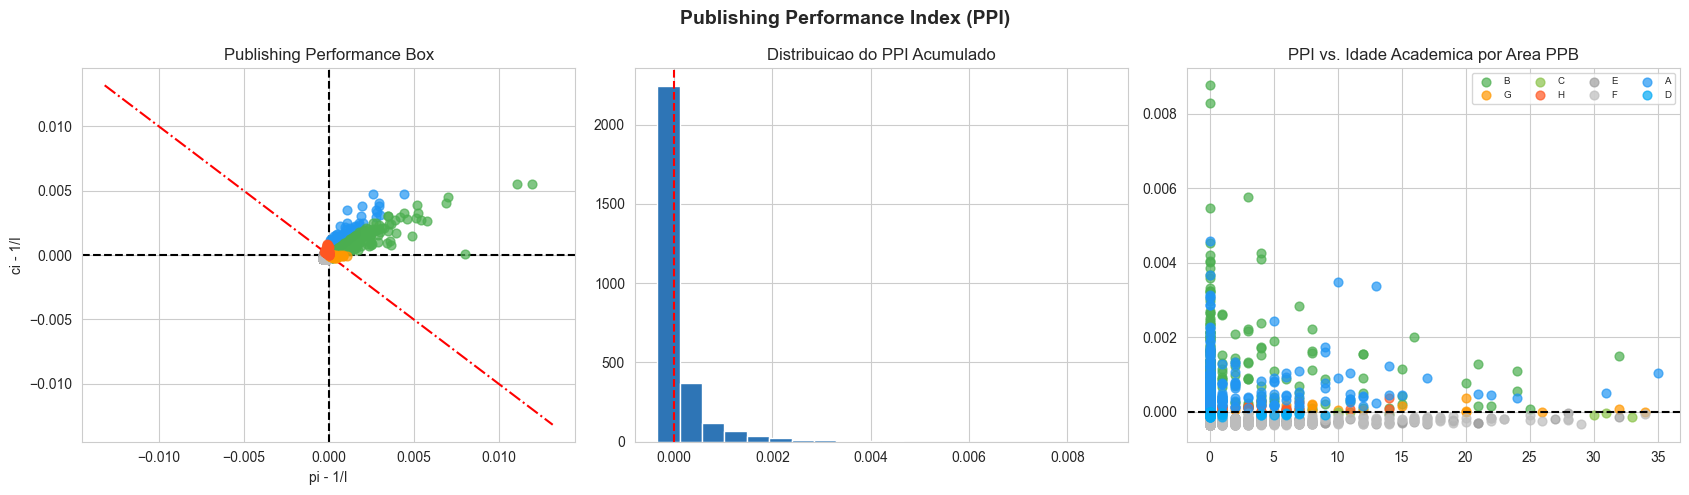

✅ PPI calculado.  Visualizacao: 0.5s


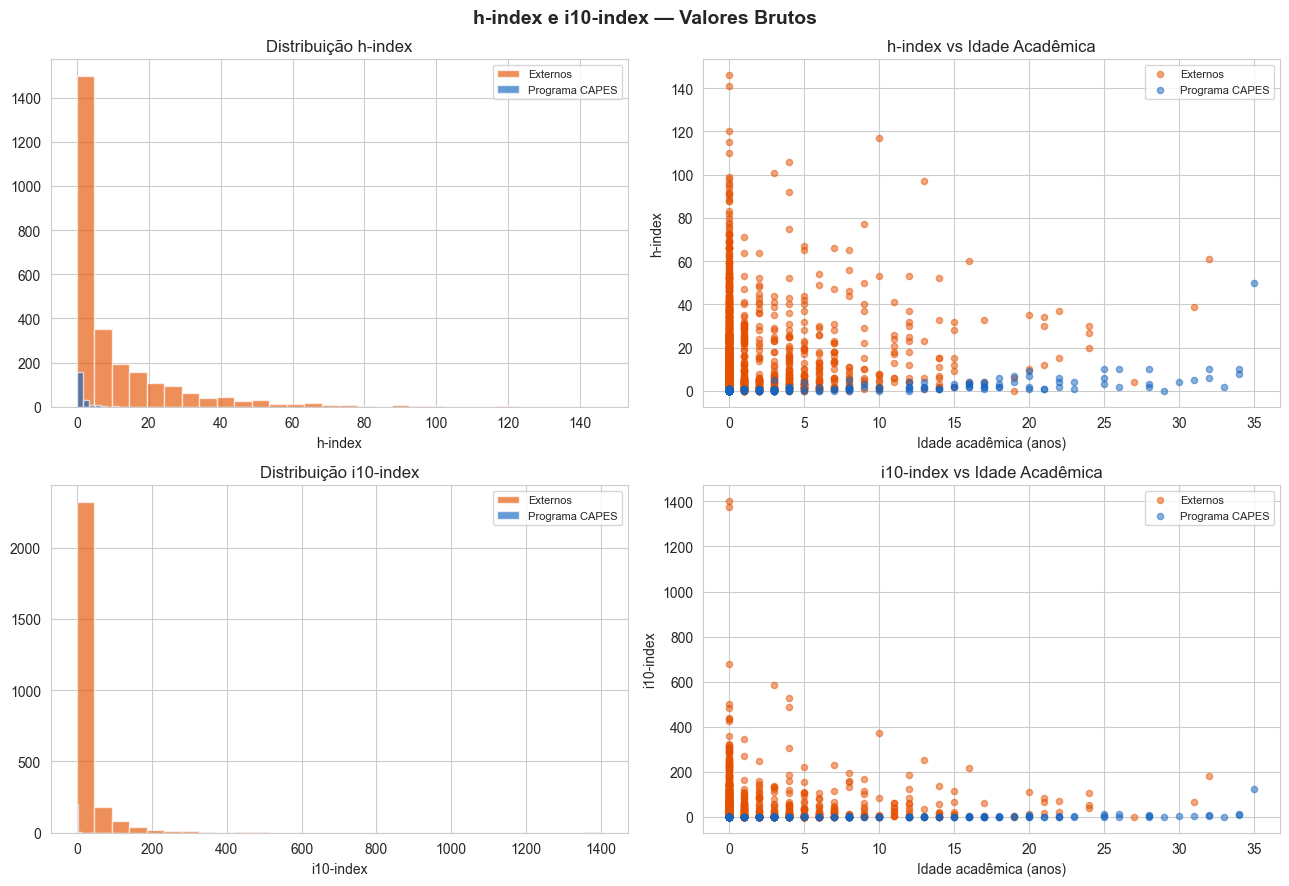

✅ h-index e i10-index (brutos) visualizados.


In [141]:
# ── Calculo PPI e Visualizacao ──────────────────────────────────────────────────────────────────────────────────

import time
from scipy.sparse import csr_matrix

first_year_by_author = df_rels.groupby("author_id")["publication_year"].min().rename("first_year")
last_year_by_author  = df_rels.groupby("author_id")["publication_year"].max().rename("last_year")
n_works_in_sample    = df_rels.groupby("author_id").size().rename("n_works_in_sample")

def compute_ppi(df, np_col, nc_col, alpha=0.5):
    I, total_np, total_nc_sq = len(df), df[np_col].sum(), np.sqrt(df[nc_col]).sum()
    p = df[np_col] / total_np if total_np > 0 else 0.0
    c = np.sqrt(df[nc_col]) / total_nc_sq if total_nc_sq > 0 else 0.0
    return alpha * (p - 1/I) + (1 - alpha) * (c - 1/I)

def ppb_area_vec(p_eq, c_eq):
    pm = p_eq.values.astype(float)
    cm = c_eq.values.astype(float)
    return np.select(
        [pd.isna(p_eq) | pd.isna(c_eq),
         (pm>=0)&(cm>=0)&(pm>=cm),
         (pm>=0)&(cm>=0)&(pm<cm),
         (pm<0)&(cm>=0)&(np.abs(pm)<cm),
         (pm<0)&(cm>=0)&(np.abs(pm)>=cm),
         (pm<0)&(cm<0)&(np.abs(pm)>=np.abs(cm)),
         (pm<0)&(cm<0)&(np.abs(pm)<np.abs(cm)),
         (pm>=0)&(cm<0)&(pm>=np.abs(cm))],
        [None, "B", "A", "H", "D", "E", "F", "G"],
        default="C"
    )

AREA_COLORS = {"A":"#2196F3","B":"#4CAF50","C":"#8BC34A","D":"#03A9F4",
               "E":"#9E9E9E","F":"#BDBDBD","G":"#FF9800","H":"#FF5722"}

# ── Profiles checkpoint (pickle for fast load; CSV fallback for compatibility) ──
CKPT_PROFILES_PQ  = CHECKPOINT_DIR / f"profiles_{ID_PROGRAMA}.pkl"
CKPT_PROFILES_CSV = CHECKPOINT_DIR / f"profiles_{ID_PROGRAMA}.csv"
_PROF_REQUIRED = {"hhi_specialization", "shannon_entropy", "PPI_accumulated",
                  "ppb_area", "p_minus_eq", "c_minus_eq"}

def _ckpt_cols(path):
    if path.suffix == ".pkl":
        return set(pd.read_pickle(path).columns)
    return set(pd.read_csv(path, nrows=0).columns)

# Prefer parquet; fall back to CSV if it exists and parquet does not
if CKPT_PROFILES_PQ.exists():
    _ckpt_path, _stale = CKPT_PROFILES_PQ, bool(_PROF_REQUIRED - _ckpt_cols(CKPT_PROFILES_PQ))
elif CKPT_PROFILES_CSV.exists():
    _ckpt_path, _stale = CKPT_PROFILES_CSV, bool(_PROF_REQUIRED - _ckpt_cols(CKPT_PROFILES_CSV))
else:
    _ckpt_path, _stale = None, True

if _stale and _ckpt_path:
    print("Profiles checkpoint desatualizado. Recalculando...")

if _ckpt_path and not _stale:
    t0 = time.perf_counter()
    if _ckpt_path.suffix == ".pkl":
        profiles = pd.read_pickle(_ckpt_path)
    else:
        profiles = pd.read_csv(_ckpt_path)
    profiles["academic_age"] = profiles["academic_age"].astype("Int64")
    print(f"Profiles checkpoint carregado: {len(profiles):,} autores  ({time.perf_counter()-t0:.1f}s)")
else:
    # ── Vectorized HHI + Shannon entropy via sparse matmul ──────────────────
    print(f"Calculando HHI e entropia ({len(df_rels['author_id'].dropna().unique()):,} autores, metodo vetorizado)...")
    t0 = time.perf_counter()

    all_author_ids = df_rels["author_id"].dropna().unique()
    author_to_idx  = {aid: i for i, aid in enumerate(all_author_ids)}
    n_authors      = len(all_author_ids)

    work_ids_list = list(W_cpu_dict.keys())
    work_to_idx   = {wid: i for i, wid in enumerate(work_ids_list)}
    n_works       = len(work_ids_list)

    df_aw = (df_rels[["author_id","work_id"]].dropna().drop_duplicates())
    df_aw = df_aw[df_aw["work_id"].isin(work_to_idx)].copy()
    df_aw["a_idx"] = df_aw["author_id"].map(author_to_idx)
    df_aw["w_idx"] = df_aw["work_id"].map(work_to_idx)
    df_aw = df_aw.dropna(subset=["a_idx","w_idx"])
    a_idx = df_aw["a_idx"].astype(int).values
    w_idx = df_aw["w_idx"].astype(int).values

    print(f"  Index maps built  ({time.perf_counter()-t0:.1f}s)")
    t1 = time.perf_counter()

    A = csr_matrix((np.ones(len(a_idx), dtype=np.float32), (a_idx, w_idx)),
                   shape=(n_authors, n_works))
    V_works = np.stack([W_cpu_dict[wid] for wid in work_ids_list]).astype(np.float32)
    print(f"  V_works stacked: {V_works.shape}  ({time.perf_counter()-t1:.1f}s)")
    t1 = time.perf_counter()

    author_sums    = np.asarray(A.dot(V_works))
    count_per_auth = np.asarray(A.sum(axis=1)).ravel()
    print(f"  Sparse matmul done  ({time.perf_counter()-t1:.1f}s)")

    valid = count_per_auth > 0
    safe_count = np.where(valid, count_per_auth, 1.0)
    author_mean = author_sums / safe_count[:, np.newaxis]
    author_mean[~valid] = 0.0
    row_sums = author_mean.sum(axis=1, keepdims=True)
    safe_rows = np.where(row_sums > 0, row_sums, 1.0)
    author_mean = author_mean / safe_rows
    author_mean[~valid] = 0.0

    hhi_vals = (author_mean ** 2).sum(axis=1)
    eps = 1e-12
    H_vals = -(author_mean * np.log2(author_mean + eps)).sum(axis=1)

    spec_df = pd.DataFrame({
        "author_id":        all_author_ids,
        "hhi_specialization": np.where(valid, hhi_vals, float("nan")),
        "shannon_entropy":    np.where(valid, H_vals,   float("nan")),
    })
    print(f"  HHI/entropy for {int(valid.sum()):,} autores  ({time.perf_counter()-t0:.1f}s total)")

    profiles = (df_authors
                .merge(first_year_by_author, on="author_id", how="left")
                .merge(last_year_by_author,  on="author_id", how="left")
                .merge(n_works_in_sample,    on="author_id", how="left")
                .merge(spec_df,              on="author_id", how="left"))
    profiles["academic_age"] = (profiles["last_year"] - profiles["first_year"]).astype("Int64")
    profiles["PPI_accumulated"] = compute_ppi(profiles, "works_count", "cited_by_count")

    N_authors = len(profiles)
    p_eq = profiles["works_count"] / profiles["works_count"].sum() - 1/N_authors
    c_eq = (np.sqrt(profiles["cited_by_count"]) / np.sqrt(profiles["cited_by_count"]).sum()
            - 1/N_authors)
    profiles["p_minus_eq"], profiles["c_minus_eq"] = p_eq, c_eq
    # Vectorized ppb_area — one numpy pass instead of 235k Python calls
    profiles["ppb_area"] = ppb_area_vec(p_eq, c_eq)

    profiles.to_pickle(CKPT_PROFILES_PQ)
    print(f"Profiles checkpoint salvo: {CKPT_PROFILES_PQ}  ({len(profiles):,} autores)")

p_eq        = profiles["p_minus_eq"]
c_eq        = profiles["c_minus_eq"]
N_authors   = len(profiles)


# Visualizacao PPI
t0 = time.perf_counter()
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Publishing Performance Index (PPI)", fontsize=14, fontweight="bold")

# axes[0] — PPB scatter: one ax.scatter() call per area (≤8), not one per row
ax = axes[0]
for area, sub in profiles.dropna(subset=["p_minus_eq","c_minus_eq"]).groupby("ppb_area"):
    ax.scatter(sub["p_minus_eq"], sub["c_minus_eq"],
               color=AREA_COLORS.get(area, "#000"), alpha=0.7, s=40, zorder=3, label=area)
ax.axhline(0, color="black", linestyle="--")
ax.axvline(0, color="black", linestyle="--")
lim = max(abs(p_eq.max()), abs(c_eq.max())) * 1.1
ax.plot([-lim, lim], [lim, -lim], color="red", linestyle="-.", label="YY' (PPI=0)")
ax.set_xlabel("pi - 1/I"); ax.set_ylabel("ci - 1/I"); ax.set_title("Publishing Performance Box")

ax = axes[1]
ax.hist(profiles["PPI_accumulated"].dropna(), bins=20, color="#2E75B6", edgecolor="white")
ax.axvline(0, color="red", linestyle="--")
ax.set_title("Distribuicao do PPI Acumulado")

ax = axes[2]
area_vals = profiles["ppb_area"].fillna("?")
for area in area_vals.unique():
    sub = profiles[area_vals == area]
    ax.scatter(sub["academic_age"], sub["PPI_accumulated"],
               color=AREA_COLORS.get(area, "#000"), alpha=0.7, s=40, label=area)
ax.axhline(0, color="black", linestyle="--")
ax.set_title("PPI vs. Idade Academica por Area PPB")
ax.legend(ncol=4, fontsize=7)

plt.tight_layout()
plt.show()
print(f"✅ PPI calculado.  Visualizacao: {time.perf_counter()-t0:.1f}s")

# ── Figura 2: h-index e i10-index (raw values) ──────────────────────────────
if "h_index" in profiles.columns:
    fig2, axes2 = plt.subplots(2, 2, figsize=(13, 9))
    fig2.suptitle("h-index e i10-index — Valores Brutos", fontsize=14, fontweight="bold")

    for row_i, (metric_name, metric_col) in enumerate([("h-index","h_index"),("i10-index","i10_index")]):
        if metric_col not in profiles.columns: continue
        ax_hist, ax_scat = axes2[row_i]

        # Distribution (split by is_programa if available)
        if "is_programa" in profiles.columns:
            for grp_val, grp_df in profiles.groupby("is_programa"):
                lbl = "Programa CAPES" if grp_val else "Externos"
                col = "#1565C0" if grp_val else "#E65100"
                ax_hist.hist(grp_df[metric_col].dropna(), bins=30, alpha=0.65,
                             color=col, edgecolor="white", label=lbl)
        else:
            ax_hist.hist(profiles[metric_col].dropna(), bins=30, color="#2E75B6", edgecolor="white")
        ax_hist.set_title(f"Distribuição {metric_name}")
        ax_hist.set_xlabel(metric_name); ax_hist.legend(fontsize=8)

        # vs Academic Age
        if "is_programa" in profiles.columns:
            for grp_val, grp_df in profiles.dropna(subset=["academic_age",metric_col]).groupby("is_programa"):
                lbl = "Programa CAPES" if grp_val else "Externos"
                col = "#1565C0" if grp_val else "#E65100"
                ax_scat.scatter(grp_df["academic_age"], grp_df[metric_col],
                                label=lbl, color=col, alpha=0.5, s=20)
        else:
            ax_scat.scatter(profiles["academic_age"], profiles[metric_col],
                            alpha=0.5, s=20, color="#2E75B6")
        ax_scat.set_title(f"{metric_name} vs Idade Acadêmica")
        ax_scat.set_xlabel("Idade acadêmica (anos)"); ax_scat.set_ylabel(metric_name)
        ax_scat.legend(fontsize=8)

    plt.tight_layout()
    plt.show()
    print("✅ h-index e i10-index (brutos) visualizados.")


### 6. Collaboration Impact Analysis — Dyads, Placebos & Research Questions

**Dyad construction** (Cell below): For every pair (focal CAPES author, collaborator) that co-authored at least one work, records the first meeting year, collaboration frequency, initial thematic distance, and pre/post drift metrics (`delta_drift_3` = mean drift of 3 papers post-meeting − 3 papers pre-meeting).  
**Placebo dyads**: random pseudo-meeting years for the same focal authors, used to check that observed drift changes are caused by the real collaboration and not by natural career progression.

**7 Research Questions** (next cell, `RQ1–RQ7`), tested with cluster-robust OLS (standard errors clustered by focal author) + Bonferroni correction:

| RQ | Hypothesis | Test |
|---|---|---|
| **RQ1** | Recurrent collaborators drive more drift than occasional ones | OLS `delta_drift_3 ~ is_recurrent` + Welch t (real vs placebo) |
| **RQ2** | Initial thematic distance predicts convergence magnitude (inverted-U) | OLS w/ quadratic `initial_thematic_dist²` |
| **RQ3** | Higher-PPI collaborators pull focal author's drift more (× frequency) | OLS `delta_drift_3 ~ ppi_diff × collab_freq_log` |
| **RQ4** | Authorship position (first/middle/last) moderates influence | OLS with `C(focal_position_at_meeting)` |
| **RQ5** | Specialist focals resist influence more (entropy × PPI interaction) | OLS `focal_entropy × ppi_diff` |
| **RQ6** | Junior collaborators can shift senior focals (senior subset) | OLS `aa_diff` on high-academic-age subset |
| **RQ7** | Low-PPI collabs shift high-PPI focals (high-PPI subset) | OLS `ppi_diff` on high-PPI subset |

**Bidirectional / Reciprocal Influence** (cell after RQ7): measures not just how much the focal author moved toward the collaborator, but also how much the collaborator moved toward the focal — producing `Y_focal→collab`, `Y_collab→focal`, `Y_liquida` (net direction), and `Y_total_convergence`.  
**Neutron Star** cases: dyads where a junior focal author disproportionately influences a more senior collaborator (`aa_diff > 0`, `Y_liquida < 0`).


In [142]:
# ── Criação de Díades, Placebos e Testes OLS ─────────────────────────────────
focal_eligible = set(timelines.groupby("author_id").size()[lambda s: s >= 2].index)
tl_by_author = {aid: grp.sort_values("publication_year").reset_index(drop=True)
                for aid, grp in timelines.groupby("author_id")}
prof_by_author = profiles.set_index("author_id")

# Restrict focal to programa authors — this is scientifically correct (we study
# CAPES researcher drift) and avoids combinatorial explosion for large programs.
# Without this, program 1733 generates ~10M pairs from 235k co-authors.
_programa_ids_set = set(df_rels.loc[df_rels["is_programa"], "author_id"].unique())
print(f"Programa authors available as focal: {len(_programa_ids_set):,}")

import time as _time
_t0 = _time.perf_counter()
raw_pairs = []
for wid, grp in df_rels.groupby("work_id"):
    auts = grp["author_id"].unique().tolist()
    if len(auts) < 2: continue
    if len(auts) > 25: continue  # skip hyper-collaborative papers (>25 authors)
    yr = int(grp["publication_year"].iloc[0])
    # Only focal = programa author; collab = any co-author
    for a in auts:
        if a not in _programa_ids_set: continue
        for b in auts:
            if a != b:
                raw_pairs.append((a, b, wid, yr))
print(f"raw_pairs: {len(raw_pairs):,}  ({_time.perf_counter()-_t0:.1f}s)")

pairs_df = pd.DataFrame(raw_pairs, columns=["focal", "collab", "work_id", "year"])
dyad_summary = pairs_df.groupby(["focal", "collab"]).agg(
    meeting_year=("year", "min"), last_collab_year=("year", "max"),
    n_joint_works=("work_id", "nunique")).reset_index()

dyad_summary["collab_span"] = dyad_summary["last_collab_year"] - dyad_summary["meeting_year"] + 1
dyad_summary["collab_freq_log"] = np.log1p(dyad_summary["n_joint_works"])
print(f"dyad_summary: {len(dyad_summary):,} unique dyads  ({_time.perf_counter()-_t0:.1f}s)")
_t0 = _time.perf_counter()

def _mean_drift(sub, k): return float(sub["drift_cos_vs_prior"].head(k).mean()) if not sub.empty else np.nan

dyad_rows, placebo_rows = [], []
RNG = np.random.default_rng(2026)

print(f"Processando {len(dyad_summary):,} diades...")
_done = 0
for _, d in dyad_summary.iterrows():
    f, c, y = d["focal"], d["collab"], int(d["meeting_year"])
    if f not in focal_eligible or f not in tl_by_author or c not in tl_by_author: continue

    tlf, tlc = tl_by_author[f], tl_by_author[c]
    pre_f  = tlf[tlf["publication_year"] < y].sort_values("publication_year")
    post_f = tlf[tlf["publication_year"] > y].sort_values("publication_year")
    prof_f, prof_c = profile_up_to(tlf, y), profile_up_to(tlc, y)

    if pre_f.empty or post_f.empty or prof_f is None or prof_c is None: continue

    initial_dist = 1.0 - cosine_sim_gpu(cp.array(prof_f), cp.array(prof_c))

    dyad_rows.append({
        "focal": f, "collab": c, "meeting_year": y,
        "n_joint_works":  int(d["n_joint_works"]),
        "collab_freq_log": d["collab_freq_log"],
        "focal_age_before":  y - int(tlf["publication_year"].min()),
        "collab_age_before": y - int(tlc["publication_year"].min()),
        "initial_thematic_dist": initial_dist,
        "drift_pre_3":  _mean_drift(pre_f.iloc[::-1], 3),
        "drift_post_3": _mean_drift(post_f, 3)
    })
    _done += 1
    if _done % 500 == 0 or _done == len(dyad_summary):
        print(f"  {_done:,}/{len(dyad_summary):,} diades  ({_time.perf_counter()-_t0:.1f}s)")

    # Placebo: pick a random year that is not the real meeting year
    years_avail = sorted(tlf["publication_year"].unique())
    placebo_candidates = [yr for yr in years_avail[1:-1] if yr != y]
    if placebo_candidates:
        fake_y  = RNG.choice(placebo_candidates)
        p_pre_f  = tlf[tlf["publication_year"] < fake_y].sort_values("publication_year")
        p_post_f = tlf[tlf["publication_year"] > fake_y].sort_values("publication_year")
        if not p_pre_f.empty and not p_post_f.empty:
            placebo_rows.append({
                "focal": f,
                "drift_pre_3":  _mean_drift(p_pre_f.iloc[::-1], 3),
                "drift_post_3": _mean_drift(p_post_f, 3)
            })

dyads    = pd.DataFrame(dyad_rows)
placebos = pd.DataFrame(placebo_rows)

if not dyads.empty:    dyads["delta_drift_3"]    = dyads["drift_post_3"]    - dyads["drift_pre_3"]
if not placebos.empty: placebos["delta_drift_3"] = placebos["drift_post_3"] - placebos["drift_pre_3"]

# Modelagem OLS — drop rows with NaN in any model variable BEFORE fitting,
# so cluster groups align with the residual matrix.
def _ols(formula, data, group_col="focal"):
    """NaN-safe cluster-robust OLS.
    Uses regex to extract column names from formula so interaction terms
    (*, :) and patsy functions (I(), C()) are handled correctly.
    """
    import re as _re
    if len(data) < 10: return None
    lhs, rhs = formula.split("~", 1)
    dep = lhs.strip()
    # Extract word tokens from RHS; keep only those that are actual column names
    tokens = set(_re.findall(r"\b([a-zA-Z_]\w*)\b", rhs))
    used_cols = list({group_col, dep} | (tokens & set(data.columns)))
    clean = data.dropna(subset=used_cols).reset_index(drop=True)
    if len(clean) < 10: return None
    return (smf.ols(formula, data=clean)
               .fit(cov_type="cluster", cov_kwds={"groups": clean[group_col]}))

print("=" * 60 + "\nPLACEBO — Colaboração real vs. pseudo-encontro\n" + "=" * 60)
if not dyads.empty and not placebos.empty:
    t_stat, p_val = stats.ttest_ind(
        dyads["delta_drift_3"].dropna(), placebos["delta_drift_3"].dropna(), equal_var=False)
    print(f"Teste t: t={t_stat:.3f}, p={p_val:.4f} {'(Impacto Sig.!)' if p_val < 0.05 else ''}")

print("\n" + "=" * 60 + "\nRQ1 / RQ2 — Impacto Frequência e Diferença Temática\n" + "=" * 60)
m1 = _ols("delta_drift_3 ~ collab_freq_log + initial_thematic_dist + focal_age_before + collab_age_before", dyads)
if m1: print(m1.summary().tables[1])

print("\n🚀 Análise e extração completas!")


Programa authors available as focal: 214
raw_pairs: 5,234  (0.4s)
dyad_summary: 2,657 unique dyads  (0.5s)
Processando 2,657 diades...
PLACEBO — Colaboração real vs. pseudo-encontro
Teste t: t=-1.112, p=0.2677 

RQ1 / RQ2 — Impacto Frequência e Diferença Temática
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.0287      0.173      0.166      0.868      -0.310       0.367
collab_freq_log          -0.0704      0.105     -0.670      0.503      -0.276       0.136
initial_thematic_dist    -0.0431      0.119     -0.361      0.718      -0.277       0.191
focal_age_before         -0.0014      0.005     -0.284      0.777      -0.011       0.008
collab_age_before         0.0016      0.005      0.334      0.738      -0.008       0.011

🚀 Análise e extração completas!


In [143]:
# ── Teste das 7 Questões de Pesquisa (RQ1–RQ7) ───────────────────────────────
# Reutiliza dyads, placebos, profiles, df_rels e o helper _ols() já definidos.

# ─── 1. Engenharia de features no nível da díade ─────────────────────────────
ppi_lookup = profiles.set_index("author_id")["PPI_accumulated"]
aa_lookup  = profiles.set_index("author_id")["academic_age"].astype("float")
ent_lookup = profiles.set_index("author_id")["shannon_entropy"]

dyads["focal_ppi"]     = dyads["focal"].map(ppi_lookup)
dyads["collab_ppi"]    = dyads["collab"].map(ppi_lookup)
dyads["ppi_diff"]      = dyads["collab_ppi"] - dyads["focal_ppi"]   # >0 → collab é mais sênior em PPI
dyads["focal_aa"]      = dyads["focal"].map(aa_lookup)
dyads["collab_aa"]     = dyads["collab"].map(aa_lookup)
dyads["aa_diff"]       = dyads["collab_aa"] - dyads["focal_aa"]    # <0 → collab é mais jovem
dyads["focal_entropy"] = dyads["focal"].map(ent_lookup)
dyads["is_recurrent"]  = (dyads["n_joint_works"] > 1).astype(int)

# h-index and i10-index differentials (same sign convention as ppi_diff)
if "PPI_h" in profiles.columns:
    h_lookup   = profiles.set_index("author_id")["h_index"]
    i10_lookup = profiles.set_index("author_id")["i10_index"]
    dyads["focal_h"]    = dyads["focal"].map(h_lookup)
    dyads["collab_h"]   = dyads["collab"].map(h_lookup)
    dyads["h_diff"]     = dyads["collab_h"] - dyads["focal_h"]
    dyads["focal_i10"]  = dyads["focal"].map(i10_lookup)
    dyads["collab_i10"] = dyads["collab"].map(i10_lookup)
    dyads["i10_diff"]   = dyads["collab_i10"] - dyads["focal_i10"]

# Posição de autoria do focal no ano do encontro (RQ4)
position_at_meeting = (df_rels
    .groupby(["author_id", "publication_year"])["author_position"]
    .agg(lambda s: s.mode().iat[0] if not s.mode().empty else None)
    .rename("focal_position_at_meeting"))
dyads = dyads.merge(position_at_meeting,
                    left_on=["focal", "meeting_year"],
                    right_index=True, how="left")

print(f"Díades disponíveis: {len(dyads)}")
print(f"  └─ com is_recurrent=1: {int(dyads['is_recurrent'].sum())}")
print(f"  └─ com posição de autoria conhecida: {dyads['focal_position_at_meeting'].notna().sum()}")

# ─── 2. Definição dos 7 testes ───────────────────────────────────────────────
# Cada entrada: (RQ, fórmula, dataset, coef de interesse).
high_aa_q  = dyads["focal_aa"].quantile(0.66)
high_ppi_q = dyads["focal_ppi"].quantile(0.66)
senior_subset   = dyads[dyads["focal_aa"]  >= high_aa_q].copy()
hi_ppi_subset   = dyads[dyads["focal_ppi"] >= high_ppi_q].copy()

rq_specs = [
    ("RQ1", "delta_drift_3 ~ is_recurrent",
            dyads, "is_recurrent"),
    ("RQ2", "delta_drift_3 ~ initial_thematic_dist + I(initial_thematic_dist**2)",
            dyads, "I(initial_thematic_dist ** 2)"),
    ("RQ3", "delta_drift_3 ~ ppi_diff * collab_freq_log + focal_age_before",
            dyads, "ppi_diff"),
    ("RQ4", "delta_drift_3 ~ C(focal_position_at_meeting, Treatment('middle')) + ppi_diff",
            dyads, "C(focal_position_at_meeting, Treatment('middle'))[T.first]"),
    ("RQ5", "delta_drift_3 ~ focal_entropy * ppi_diff",
            dyads, "focal_entropy:ppi_diff"),
    ("RQ6", "delta_drift_3 ~ aa_diff",
            senior_subset, "aa_diff"),
    ("RQ7", "delta_drift_3 ~ ppi_diff",
            hi_ppi_subset, "ppi_diff"),
]

# h-index and i10-index variants of RQ3 and RQ7
if "h_diff" in dyads.columns:
    hi_h_q   = dyads["focal_h"].quantile(0.66)   # focal.h_index threshold
    hi_i10_q = dyads["focal_i10"].quantile(0.66) # focal.i10_index threshold
    rq_specs += [
        ("RQ3_h",   "delta_drift_3 ~ h_diff * collab_freq_log + focal_age_before",
                    dyads, "h_diff"),
        ("RQ3_i10", "delta_drift_3 ~ i10_diff * collab_freq_log + focal_age_before",
                    dyads, "i10_diff"),
        ("RQ7_h",   "delta_drift_3 ~ h_diff",
                    dyads[dyads["focal_h"]   >= hi_h_q].copy(),   "h_diff"),
        ("RQ7_i10", "delta_drift_3 ~ i10_diff",
                    dyads[dyads["focal_i10"] >= hi_i10_q].copy(), "i10_diff"),
    ]

# ─── 3. Executar e coletar resultados ────────────────────────────────────────
results_rows = []
fitted_models = {}
for rq, formula, data, focal_coef in rq_specs:
    model = _ols(formula, data, group_col="focal")
    if model is None:
        results_rows.append({
            "RQ": rq, "n": len(data.dropna(subset=["delta_drift_3", "focal"])),
            "coef_of_interest": focal_coef, "coef": np.nan,
            "std_err": np.nan, "t": np.nan, "p_raw": np.nan
        })
        continue
    fitted_models[rq] = model
    if focal_coef in model.params.index:
        coef    = model.params[focal_coef]
        se      = model.bse[focal_coef]
        tval    = model.tvalues[focal_coef]
        pval    = model.pvalues[focal_coef]
    else:
        # Fallback: take the largest |t| among non-intercept terms
        non_int = [k for k in model.params.index if k != "Intercept"]
        if non_int:
            k = max(non_int, key=lambda k: abs(model.tvalues[k]))
            coef, se, tval, pval = model.params[k], model.bse[k], model.tvalues[k], model.pvalues[k]
            focal_coef = k + "  (fallback)"
        else:
            coef = se = tval = pval = np.nan
    results_rows.append({
        "RQ": rq, "n": int(model.nobs),
        "coef_of_interest": focal_coef, "coef": coef,
        "std_err": se, "t": tval, "p_raw": pval
    })

results = pd.DataFrame(results_rows)

# Bonferroni
n_tests = results["p_raw"].notna().sum()
results["p_bonferroni"] = (results["p_raw"] * n_tests).clip(upper=1.0)
def _stars(p):
    if pd.isna(p): return ""
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return ""
results["sig_bonf"] = results["p_bonferroni"].apply(_stars)

# ─── 4. RQ1 placebo (real vs pseudo-encontros) — controle adicional ──────────
print("=" * 72 + "\nRQ1 — Placebo: drift real vs pseudo-encontro\n" + "=" * 72)
if not dyads.empty and not placebos.empty:
    t_stat, p_val = stats.ttest_ind(
        dyads["delta_drift_3"].dropna(),
        placebos["delta_drift_3"].dropna(),
        equal_var=False)
    print(f"Welch t = {t_stat:.3f},  p = {p_val:.4f}  "
          f"{'(efeito da colaboração real significativo)' if p_val < 0.05 else '(não distinguível do placebo)'}")
else:
    print("Sem placebos disponíveis.")

# ─── 5. Tabela resumo ────────────────────────────────────────────────────────
print("\n" + "=" * 72 + f"\nResumo dos {len(rq_specs)} RQs (cluster-robusto por focal)\n" + "=" * 72)
print(results.to_string(index=False,
    formatters={"coef": "{:.4f}".format, "std_err": "{:.4f}".format,
                "t": "{:.2f}".format, "p_raw": "{:.4f}".format,
                "p_bonferroni": "{:.4f}".format}))

print("\nLegenda:  ** p<0.01 (Bonferroni),  * p<0.05 (Bonferroni)")

# Avisos de amostra pequena
small = results[results["n"] < 30]
if not small.empty:
    print(f"\n⚠️  RQ(s) com n<30 (interpretar com cautela): {small['RQ'].tolist()}")

# ─── 6. Persistir tabela ─────────────────────────────────────────────────────
RQ_OUT = CHECKPOINT_DIR / f"rq_results_{ID_PROGRAMA}.csv"
results.to_csv(RQ_OUT, index=False)
print(f"\n💾 Resultados salvos em {RQ_OUT}")


Díades disponíveis: 87
  └─ com is_recurrent=1: 39
  └─ com posição de autoria conhecida: 87
RQ1 — Placebo: drift real vs pseudo-encontro
Welch t = -1.112,  p = 0.2677  (não distinguível do placebo)

Resumo dos 7 RQs (cluster-robusto por focal)
 RQ  n                                           coef_of_interest     coef  std_err     t  p_raw p_bonferroni sig_bonf
RQ1 77                                               is_recurrent  -0.0906   0.0826 -1.10 0.2732       1.0000         
RQ2 75                              I(initial_thematic_dist ** 2)   0.1481   0.5217  0.28 0.7765       1.0000         
RQ3 77                                                   ppi_diff 212.2821 293.4820  0.72 0.4695       1.0000         
RQ4 77 C(focal_position_at_meeting, Treatment('middle'))[T.first]   0.0860   0.1142  0.75 0.4512       1.0000         
RQ5 77                                     focal_entropy:ppi_diff  99.5792  54.2925  1.83 0.0666       0.4664         
RQ6 30                                   

✅ Checkpoint bidirecional carregado: 60 díades

Díades bidirecional: 60
  Y_liquida válidas:          58
  Y_total_convergence válidas:58

INFLUÊNCIA RECÍPROCA — Modelos de Direção e Magnitude

── Modelo 1: Direção (Y_liquida) ──
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
Intercept                                                     -0.0285      0.073     -0.388      0.698      -0.172       0.115
C(focal_position_at_meeting, Treatment('middle'))[T.first]    -0.1266      0.083     -1.522      0.128      -0.290       0.036
C(focal_position_at_meeting, Treatment('middle'))[T.last]      0.2190      0.087      2.503      0.012       0.048       0.390
aa_diff                                                       -0.0027      0.003     -0.861      0.389      -0.009       0.003
ppi_diff

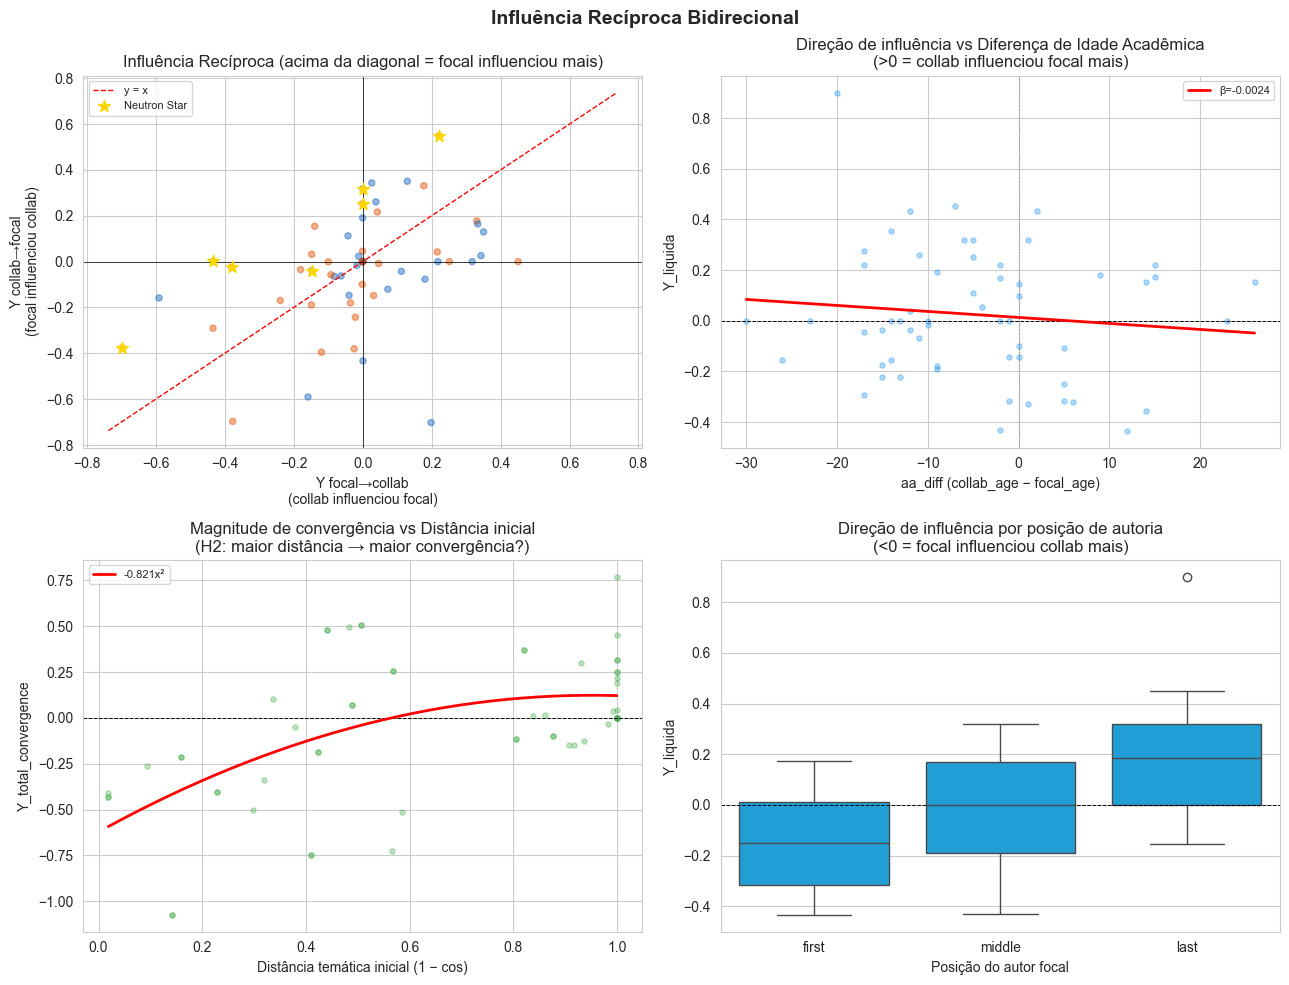

✅ Visualizações bidirecional geradas.

✅ Análise de influência recíproca concluída.


In [144]:
# ── Análise de Influência Recíproca (Bidirecional) ────────────────────────────
# Adapta os Modelos 1 e 2 do script R (hypothesis_testing_script.R):
#   Model 1 — Direção da influência: Y_liquida ~ aa_diff + ppi_diff + posição
#   Model 2 — Magnitude da convergência: Y_total ~ dist_inicial + shannon_diff
#   Neutron Star — quando autor focal júnior influencia mais o colaborador sênior

import time as _time_bidi

# ── Helper: perfil temático dos k primeiros papers APÓS o encontro ─────────────
def profile_after(tl_author: pd.DataFrame, year: int, k: int = 3,
                  next_collab_year: int | None = None):
    mask = tl_author["publication_year"] > year
    if next_collab_year is not None:
        mask &= tl_author["publication_year"] < next_collab_year
    sub = (tl_author[mask]
           .sort_values("publication_year")
           .head(k)["topic_vec"])
    if sub.empty:
        return None
    vecs = cp.array(np.stack(sub.to_list()))
    return cp.mean(vecs, axis=0)

# ── Part 1: Cálculo das Y bidirecional ────────────────────────────────────────
CKPT_BIDI = CHECKPOINT_DIR / f"bidi_dyads_{ID_PROGRAMA}.csv"
_BIDI_REQUIRED = {"Y_focal_to_collab", "Y_collab_to_focal", "Y_liquida", "Y_total_convergence"}

_bidi_stale = (CKPT_BIDI.exists()
               and bool(_BIDI_REQUIRED - set(pd.read_csv(CKPT_BIDI, nrows=0).columns)))

if CKPT_BIDI.exists() and not _bidi_stale:
    dyads_bidi = pd.read_csv(CKPT_BIDI)
    print(f"✅ Checkpoint bidirecional carregado: {len(dyads_bidi)} díades")
else:
    print(f"⌛ Calculando Y bidirecional para {len(dyads)} díades...")
    _t0 = _time_bidi.perf_counter()
    bidi_rows = []

    # next meeting year per focal-collab pair — bounds the post-collab window
    _next_yr = (dyads.sort_values("meeting_year")
                .groupby(["focal", "collab"])["meeting_year"]
                .shift(-1))
    dyads = dyads.copy()
    dyads["_next_collab_year"] = _next_yr.values

    for _, d in dyads.iterrows():
        f, c, y = d["focal"], d["collab"], int(d["meeting_year"])
        if f not in tl_by_author or c not in tl_by_author:
            continue

        tlf, tlc = tl_by_author[f], tl_by_author[c]

        _next_y = d["_next_collab_year"]
        next_y  = None if pd.isna(_next_y) else int(_next_y)

        prof_fp = profile_up_to(tlf, y)                                 # focal pré
        prof_cp = profile_up_to(tlc, y)                                 # collab pré
        prof_fq = profile_after(tlf, y, k=3, next_collab_year=next_y)  # focal pós
        prof_cq = profile_after(tlc, y, k=3, next_collab_year=next_y)  # collab pós

        if any(p is None for p in [prof_fp, prof_cp, prof_fq, prof_cq]):
            continue

        dist_ini  = 1.0 - cosine_sim_gpu(cp.array(prof_fp), cp.array(prof_cp))
        dist_fp_cp = 1.0 - cosine_sim_gpu(cp.array(prof_fq), cp.array(prof_cp))
        dist_cq_fp = 1.0 - cosine_sim_gpu(cp.array(prof_cq), cp.array(prof_fp))

        bidi_rows.append({
            "focal": f, "collab": c, "meeting_year": y,
            "Y_focal_to_collab": dist_ini - dist_fp_cp,  # focal se aproximou do collab
            "Y_collab_to_focal": dist_ini - dist_cq_fp,  # collab se aproximou do focal
        })

    df_bidi = pd.DataFrame(bidi_rows)
    print(f"  {len(df_bidi)} díades com dados completos  ({_time_bidi.perf_counter()-_t0:.1f}s)")

    dyads_bidi = dyads.merge(
        df_bidi[["focal", "collab", "meeting_year", "Y_focal_to_collab", "Y_collab_to_focal"]],
        on=["focal", "collab", "meeting_year"], how="inner"
    )
    dyads_bidi["Y_liquida"]           = dyads_bidi["Y_focal_to_collab"] - dyads_bidi["Y_collab_to_focal"]
    dyads_bidi["Y_total_convergence"] = dyads_bidi["Y_focal_to_collab"] + dyads_bidi["Y_collab_to_focal"]

    # ── Part 2: Features adicionais ───────────────────────────────────────────
    ent_lookup = profiles.set_index("author_id")["shannon_entropy"]
    dyads_bidi["collab_entropy"] = dyads_bidi["collab"].map(ent_lookup)
    dyads_bidi["shannon_diff"]   = dyads_bidi["focal_entropy"] - dyads_bidi["collab_entropy"]

    dyads_bidi.to_csv(CKPT_BIDI, index=False)
    print(f"💾 Checkpoint bidirecional salvo: {CKPT_BIDI}")

print(f"\nDíades bidirecional: {len(dyads_bidi)}")
print(f"  Y_liquida válidas:          {dyads_bidi['Y_liquida'].notna().sum()}")
print(f"  Y_total_convergence válidas:{dyads_bidi['Y_total_convergence'].notna().sum()}")

# Garantir colunas de features necessárias (caso carregado do checkpoint)
if "shannon_diff" not in dyads_bidi.columns:
    ent_lookup = profiles.set_index("author_id")["shannon_entropy"]
    dyads_bidi["collab_entropy"] = dyads_bidi["collab"].map(ent_lookup)
    dyads_bidi["shannon_diff"]   = dyads_bidi["focal_entropy"] - dyads_bidi["collab_entropy"]

# ── Part 3: Modelos OLS ───────────────────────────────────────────────────────
print("\n" + "=" * 72)
print("INFLUÊNCIA RECÍPROCA — Modelos de Direção e Magnitude")
print("=" * 72)

# Model 1: Direção da influência líquida
# Y_liquida > 0 → collab influenciou mais o focal
# aa_diff > 0  → collab é mais sênior (mais idade acadêmica)
print("\n── Modelo 1: Direção (Y_liquida) ──")
m_dir = _ols(
    "Y_liquida ~ aa_diff + ppi_diff + C(focal_position_at_meeting, Treatment('middle'))",
    dyads_bidi, group_col="focal"
)
if m_dir:
    print(m_dir.summary().tables[1])
else:
    print("⚠️  Dados insuficientes para Modelo 1 (n < 10)")

# Model 2: Magnitude da convergência total
print("\n── Modelo 2: Magnitude (Y_total_convergence) ──")
m_mag = _ols(
    "Y_total_convergence ~ initial_thematic_dist + I(initial_thematic_dist**2) + shannon_diff",
    dyads_bidi, group_col="focal"
)
if m_mag:
    print(m_mag.summary().tables[1])
else:
    print("⚠️  Dados insuficientes para Modelo 2 (n < 10)")

# Variantes com h-index / i10-index
if "h_diff" in dyads_bidi.columns:
    print("\n── Modelo 1-h: Direção usando h_diff ──")
    m_dir_h = _ols(
        "Y_liquida ~ h_diff + ppi_diff + C(focal_position_at_meeting, Treatment('middle'))",
        dyads_bidi, group_col="focal"
    )
    if m_dir_h:
        print(m_dir_h.summary().tables[1])

# ── Tabela resumo com Bonferroni ──────────────────────────────────────────────
_bidi_specs = [
    ("M1_dir",  "Y_liquida ~ aa_diff + ppi_diff + C(focal_position_at_meeting, Treatment('middle'))",
     dyads_bidi, "aa_diff"),
    ("M2_mag",  "Y_total_convergence ~ initial_thematic_dist + I(initial_thematic_dist**2) + shannon_diff",
     dyads_bidi, "initial_thematic_dist"),
]
if "h_diff" in dyads_bidi.columns:
    _bidi_specs.append(
        ("M1_dir_h", "Y_liquida ~ h_diff + ppi_diff + C(focal_position_at_meeting, Treatment('middle'))",
         dyads_bidi, "h_diff")
    )

bidi_rows_res = []
for rq, formula, data, focal_coef in _bidi_specs:
    mdl = _ols(formula, data, group_col="focal")
    if mdl is None:
        bidi_rows_res.append({"RQ": rq, "n": len(data.dropna(subset=["focal"])),
                              "coef_of_interest": focal_coef,
                              "coef": np.nan, "std_err": np.nan, "t": np.nan, "p_raw": np.nan})
        continue
    if focal_coef in mdl.params.index:
        coef, se, tval, pval = (mdl.params[focal_coef], mdl.bse[focal_coef],
                                mdl.tvalues[focal_coef], mdl.pvalues[focal_coef])
    else:
        non_int = [k for k in mdl.params.index if k != "Intercept"]
        if non_int:
            k = max(non_int, key=lambda k: abs(mdl.tvalues[k]))
            coef, se, tval, pval = mdl.params[k], mdl.bse[k], mdl.tvalues[k], mdl.pvalues[k]
            focal_coef = k + "  (fallback)"
        else:
            coef = se = tval = pval = np.nan
    bidi_rows_res.append({"RQ": rq, "n": int(mdl.nobs), "coef_of_interest": focal_coef,
                          "coef": coef, "std_err": se, "t": tval, "p_raw": pval})

bidi_results = pd.DataFrame(bidi_rows_res)
n_bidi = bidi_results["p_raw"].notna().sum()
bidi_results["p_bonferroni"] = (bidi_results["p_raw"] * max(n_bidi, 1)).clip(upper=1.0)
bidi_results["sig_bonf"] = bidi_results["p_bonferroni"].apply(
    lambda p: "**" if pd.notna(p) and p < 0.01 else ("*" if pd.notna(p) and p < 0.05 else ""))

print("\n" + "=" * 72 + f"\nResumo bidirecional ({len(_bidi_specs)} modelos, cluster-robusto por focal)\n" + "=" * 72)
print(bidi_results.to_string(index=False,
    formatters={"coef": "{:.4f}".format, "std_err": "{:.4f}".format,
                "t": "{:.2f}".format, "p_raw": "{:.4f}".format,
                "p_bonferroni": "{:.4f}".format}))

# ── Part 4: Neutron Star ──────────────────────────────────────────────────────
# aa_diff > 0 → collab é mais sênior; Y_liquida < 0 → focal influenciou collab mais
print("\n" + "=" * 72 + "\nNeutron Star — focal júnior influencia collab sênior\n" + "=" * 72)
_ns_mask = (dyads_bidi["aa_diff"] > 0) & (dyads_bidi["Y_liquida"] < 0)
neutron_stars = dyads_bidi[_ns_mask].copy()
print(f"Casos neutron star: {len(neutron_stars)} de {dyads_bidi['Y_liquida'].notna().sum()} díades válidas "
      f"({100*len(neutron_stars)/max(dyads_bidi['Y_liquida'].notna().sum(),1):.1f}%)")

if not neutron_stars.empty:
    _ns_cols = [c for c in ["aa_diff", "ppi_diff", "shannon_diff",
                             "Y_liquida", "initial_thematic_dist"] if c in neutron_stars.columns]
    print(neutron_stars[_ns_cols].describe().to_string())

# ── Part 5: Visualizações ─────────────────────────────────────────────────────
_db = dyads_bidi.dropna(subset=["Y_focal_to_collab", "Y_collab_to_focal",
                                 "Y_liquida", "Y_total_convergence"])

if len(_db) >= 5:
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    fig.suptitle("Influência Recíproca Bidirecional", fontsize=14, fontweight="bold")

    # 1. Scatter recíproco: Y_focal→collab vs Y_collab→focal
    ax = axes[0, 0]
    _rec = _db.dropna(subset=["Y_focal_to_collab", "Y_collab_to_focal"])
    col_map = _rec["is_recurrent"].map({1: "#1565C0", 0: "#E65100"}) if "is_recurrent" in _rec.columns else "#1565C0"
    ax.scatter(_rec["Y_focal_to_collab"], _rec["Y_collab_to_focal"],
               c=col_map, alpha=0.45, s=20)
    _lim = max(abs(_rec[["Y_focal_to_collab","Y_collab_to_focal"]].values).max() * 1.05, 0.01)
    ax.plot([-_lim, _lim], [-_lim, _lim], "r--", linewidth=1, label="y = x")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_xlabel("Y focal→collab\n(collab influenciou focal)")
    ax.set_ylabel("Y collab→focal\n(focal influenciou collab)")
    ax.set_title("Influência Recíproca (acima da diagonal = focal influenciou mais)")
    ax.legend(fontsize=8)
    if not neutron_stars.empty:
        _ns_plot = neutron_stars.dropna(subset=["Y_focal_to_collab","Y_collab_to_focal"])
        ax.scatter(_ns_plot["Y_focal_to_collab"], _ns_plot["Y_collab_to_focal"],
                   marker="*", s=80, color="gold", zorder=5, label="Neutron Star")
        ax.legend(fontsize=8)

    # 2. Y_liquida vs aa_diff
    ax = axes[0, 1]
    _d2 = _db.dropna(subset=["aa_diff", "Y_liquida"])
    ax.scatter(_d2["aa_diff"], _d2["Y_liquida"], alpha=0.35, s=14, color="#2196F3")
    ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
    ax.axvline(0, color="gray", linestyle=":", linewidth=0.7)
    if len(_d2) >= 5:
        _coef = np.polyfit(_d2["aa_diff"], _d2["Y_liquida"], 1)
        _xs = np.linspace(_d2["aa_diff"].min(), _d2["aa_diff"].max(), 200)
        ax.plot(_xs, np.polyval(_coef, _xs), color="red", linewidth=2,
                label=f"β={_coef[0]:.4f}")
        ax.legend(fontsize=8)
    ax.set_xlabel("aa_diff (collab_age − focal_age)")
    ax.set_ylabel("Y_liquida")
    ax.set_title("Direção de influência vs Diferença de Idade Acadêmica\n(>0 = collab influenciou focal mais)")

    # 3. Y_total_convergence vs initial_thematic_dist
    ax = axes[1, 0]
    _d3 = _db.dropna(subset=["initial_thematic_dist", "Y_total_convergence"])
    ax.scatter(_d3["initial_thematic_dist"], _d3["Y_total_convergence"],
               alpha=0.35, s=14, color="#4CAF50")
    ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
    if len(_d3) >= 10:
        _coef2 = np.polyfit(_d3["initial_thematic_dist"], _d3["Y_total_convergence"], 2)
        _xs2 = np.linspace(_d3["initial_thematic_dist"].min(),
                           _d3["initial_thematic_dist"].max(), 200)
        ax.plot(_xs2, np.polyval(_coef2, _xs2), color="red", linewidth=2,
                label=f"{_coef2[0]:.3f}x²")
        ax.legend(fontsize=8)
    ax.set_xlabel("Distância temática inicial (1 − cos)")
    ax.set_ylabel("Y_total_convergence")
    ax.set_title("Magnitude de convergência vs Distância inicial\n(H2: maior distância → maior convergência?)")

    # 4. Y_liquida por posição de autoria (boxplot)
    ax = axes[1, 1]
    _d4 = _db.dropna(subset=["focal_position_at_meeting", "Y_liquida"])
    _pos_order = [p for p in ["first", "middle", "last"]
                  if p in _d4["focal_position_at_meeting"].unique()]
    if _pos_order:
        sns.boxplot(data=_d4, x="focal_position_at_meeting", y="Y_liquida",
                    order=_pos_order, ax=ax, color="#03A9F4")
        ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
        ax.set_xlabel("Posição do autor focal")
        ax.set_ylabel("Y_liquida")
        ax.set_title("Direção de influência por posição de autoria\n(<0 = focal influenciou collab mais)")
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "Sem dados de posição", ha="center", va="center")

    plt.tight_layout()
    plt.show()
    print("✅ Visualizações bidirecional geradas.")
else:
    print(f"⚠️  Apenas {len(_db)} díades válidas — visualizações omitidas (mínimo: 5).")

print("\n✅ Análise de influência recíproca concluída.")


### 💾 Data Export & Reports

The following cells export all processed datasets to CSV and generate four PDF reports:

| Cell | Output file | Contents |
|---|---|---|
| **Cell below** | `relatorio_{ID}.pdf` | Main report — PPI, drift, RQ1–7, institutions (Programa CAPES vs Externos) |
| **+1** | `relatorio_{ID}_capes.pdf` | Same, restricted to CAPES program researchers only |
| **+2** | `relatorio_{ID}_bidirecional.pdf` | Reciprocal influence, Neutron Star analysis, bidirectional OLS models |
| **+3** | `relatorio_{ID}_cross_field.pdf` | Interdisciplinary collaboration evolution across domain / field / subfield / topic |

All CSV datasets (`df_works`, `df_rels`, `df_authors`, `profiles`, `dyads`, `placebos`, `rq_results`) are also exported to `export/{ID}/`.


In [145]:
# ── Exportação: CSVs + Relatório PDF (dois grupos: Programa CAPES vs Externos) ─────────────────
#
# Viz escolhidas por data-to-viz.com para cada insight:
#   • PPI por grupo (1 num × 1 cat)              → histograma sobrepostos + boxplot
#   • PPB area por grupo (1 cat × 1 cat)         → barras agrupadas
#   • PPI × academic_age por grupo (2 num)       → scatter (duas séries)
#   • Drift ao longo do tempo por grupo          → boxplot por ano (duas séries)
#   • Real vs placebo por grupo                  → violin (hue=grupo)
#   • Recorrente vs ocasional por grupo          → boxplot (hue=grupo)
#   • Distância inicial × Δ drift por grupo      → scatter + ajuste quadrático (duas séries)
#   • Posição autoria × Δ drift por grupo        → boxplot (hue=grupo)
#   • Top 15 instituições: programa vs externos  → lollipop lado a lado
#   • Tabela de RQs                              → matplotlib table
#
# Saída: export/<ID_PROGRAMA>/  com CSVs + relatorio_<ID>.pdf

from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

EXPORT_DIR = Path("export") / ID_PROGRAMA
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# ── Rótulos e paleta dos dois grupos ──────────────────────────────────────────
GRP_LABEL   = {True: "Programa CAPES", False: "Externos"}
GRP_PALETTE = {True: "#1565C0", False: "#E65100"}   # azul escuro vs laranja escuro
GRP_ALPHA   = {True: 0.75, False: 0.55}

# ── Enriquecer DataFrames com is_programa onde necessário ─────────────────────
programa_author_ids = set(df_rels.loc[df_rels["is_programa"], "author_id"].unique())

# timelines: juntar is_programa pelo author_id
if "is_programa" not in timelines.columns:
    timelines["is_programa"] = timelines["author_id"].isin(programa_author_ids)

# profiles: já vem de df_authors que tem is_programa
if "is_programa" not in profiles.columns:
    profiles["is_programa"] = profiles["author_id"].isin(programa_author_ids)

# dyads: focal é programa?
if "focal_is_programa" not in dyads.columns:
    dyads["focal_is_programa"] = dyads["focal"].isin(programa_author_ids)

# ── 1. CSVs dos datasets-chave ──────────────────────────────────────────────
CSV_TARGETS = {
    "df_filtered_authors": df_filtered_authors,
    "df_works":            df_works,
    "df_rels":             df_rels,
    "df_authors":          df_authors,
    "profiles":            profiles,
    "dyads":               dyads,
    "placebos":            placebos,
    "rq_results":          results,
}
print("Exportando CSVs...")
for name, obj in CSV_TARGETS.items():
    if isinstance(obj, pd.DataFrame) and not obj.empty:
        path = EXPORT_DIR / f"{name}.csv"
        obj.to_csv(path, index=False, encoding="utf-8-sig")
        print(f"   ok {path.name}  ({len(obj)} linhas)")

# ── 2. Relatório PDF ────────────────────────────────────────────────────────
sns.set_style("whitegrid")
PDF_PATH = EXPORT_DIR / f"relatorio_{ID_PROGRAMA}.pdf"
print(f"\nConstruindo {PDF_PATH.name}...")

def _save(pdf, fig):
    fig.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

def _legend_patches():
    import matplotlib.patches as mpatches
    return [mpatches.Patch(color=GRP_PALETTE[True],  label=GRP_LABEL[True]),
            mpatches.Patch(color=GRP_PALETTE[False], label=GRP_LABEL[False])]

with PdfPages(PDF_PATH) as pdf:

    # ── Capa ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8.5, 11))
    ax.axis("off")
    ax.text(0.5, 0.78, "Relatório Bibliométrico", ha="center", fontsize=24, fontweight="bold")
    ax.text(0.5, 0.71, f"Programa CAPES {ID_PROGRAMA}", ha="center", fontsize=16, color="#555")
    ax.text(0.5, 0.69, NOME_PROGRAMA, ha="center", fontsize=13, color="#444")
    ax.text(0.5, 0.66, NOME_FACULDADE, ha="center", fontsize=11, color="#666")
    n_prog = int(profiles["is_programa"].sum()) if "is_programa" in profiles.columns else "?"
    n_ext  = len(profiles) - n_prog if isinstance(n_prog, int) else "?"
    ax.text(0.5, 0.56,
            f"Pesquisadores do programa: {len(df_filtered_authors)}\n"
            f"Autores em profiles — programa: {n_prog}  |  externos: {n_ext}\n"
            f"Obras únicas: {len(df_works)}\n"
            f"Co-autores únicos: {len(df_authors)}\n"
            f"Díades de colaboração: {len(dyads)}",
            ha="center", fontsize=12)
    ax.text(0.5, 0.10, "Pipeline CAPES + OpenAlex (pyalex)",
            ha="center", fontsize=10, color="#888", style="italic")
    ax.legend(handles=_legend_patches(), loc="lower center", fontsize=11,
              bbox_to_anchor=(0.5, 0.18), frameon=False)
    _save(pdf, fig)

    # ── 1. PPI: histogramas sobrepostos + boxplot lado a lado ────────────────
    if "PPI_accumulated" in profiles.columns and profiles["PPI_accumulated"].notna().any():
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle("PPI — Programa CAPES vs Externos", fontsize=14, fontweight="bold")
        for grp_val, grp_df in profiles.groupby("is_programa"):
            vals = grp_df["PPI_accumulated"].dropna()
            lbl  = GRP_LABEL[grp_val]
            col  = GRP_PALETTE[grp_val]
            axes[0].hist(vals, bins=25, alpha=GRP_ALPHA[grp_val],
                         color=col, edgecolor="white", label=lbl)
        axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
        axes[0].set_title("Distribuição (histograma sobreposto)")
        axes[0].set_xlabel("PPI acumulado")
        axes[0].legend()

        grp_order = [True, False]
        grp_labels = [GRP_LABEL[g] for g in grp_order]
        data_bp = [profiles.loc[profiles["is_programa"] == g, "PPI_accumulated"].dropna()
                   for g in grp_order]
        bp = axes[1].boxplot(data_bp, labels=grp_labels, patch_artist=True)
        for patch, grp_val in zip(bp["boxes"], grp_order):
            patch.set_facecolor(GRP_PALETTE[grp_val])
            patch.set_alpha(0.75)
        axes[1].axhline(0, color="red", linestyle="--", linewidth=0.8)
        axes[1].set_title("Dispersão (boxplot)")
        axes[1].set_ylabel("PPI acumulado")
        _save(pdf, fig)

    # ── 2. PPB area: barras agrupadas ────────────────────────────────────────
    if "ppb_area" in profiles.columns and "is_programa" in profiles.columns:
        AREA_COLORS = {"A":"#2196F3","B":"#4CAF50","C":"#8BC34A","D":"#03A9F4",
                       "E":"#9E9E9E","F":"#BDBDBD","G":"#FF9800","H":"#FF5722"}
        areas = sorted(profiles["ppb_area"].dropna().unique())
        x = np.arange(len(areas))
        width = 0.35
        prog_counts = profiles[profiles["is_programa"]]["ppb_area"].value_counts()
        ext_counts  = profiles[~profiles["is_programa"]]["ppb_area"].value_counts()

        fig, ax = plt.subplots(figsize=(10, 4.5))
        bars1 = ax.bar(x - width/2, [prog_counts.get(a, 0) for a in areas],
                       width, label=GRP_LABEL[True],  color=GRP_PALETTE[True],  alpha=0.8)
        bars2 = ax.bar(x + width/2, [ext_counts.get(a, 0) for a in areas],
                       width, label=GRP_LABEL[False], color=GRP_PALETTE[False], alpha=0.8)
        ax.set_xticks(x); ax.set_xticklabels(areas)
        ax.set_title("Áreas PPB por grupo", fontweight="bold")
        ax.set_ylabel("Pesquisadores"); ax.legend()
        _save(pdf, fig)

    # ── 3. PPI × Academic Age (scatter, duas séries) ─────────────────────────
    if {"academic_age","PPI_accumulated","is_programa"}.issubset(profiles.columns):
        fig, ax = plt.subplots(figsize=(10, 5.5))
        for grp_val, grp_df in profiles.dropna(subset=["academic_age","PPI_accumulated"]).groupby("is_programa"):
            ax.scatter(grp_df["academic_age"], grp_df["PPI_accumulated"],
                       label=GRP_LABEL[grp_val], color=GRP_PALETTE[grp_val],
                       alpha=GRP_ALPHA[grp_val], s=40)
        ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
        ax.set_xlabel("Idade acadêmica (anos)")
        ax.set_ylabel("PPI acumulado")
        ax.set_title("PPI vs. Idade Acadêmica — Programa CAPES vs Externos", fontweight="bold")
        ax.legend()
        _save(pdf, fig)

    # ── 4. Drift ao longo do tempo por grupo (boxplot por ano) ───────────────
    if "drift_cos_vs_prior" in timelines.columns and "is_programa" in timelines.columns:
        tl = timelines.dropna(subset=["drift_cos_vs_prior"])
        tl = tl[tl["publication_year"] >= tl["publication_year"].max() - 14].copy()
        tl["grupo"] = tl["is_programa"].map(GRP_LABEL)
        if not tl.empty:
            fig, ax = plt.subplots(figsize=(13, 5))
            sns.boxplot(data=tl, x="publication_year", y="drift_cos_vs_prior",
                        hue="grupo", palette={GRP_LABEL[True]: GRP_PALETTE[True],
                                              GRP_LABEL[False]: GRP_PALETTE[False]},
                        ax=ax, fliersize=1.5, linewidth=0.8)
            ax.set_title("Drift temático por ano e grupo", fontweight="bold")
            ax.set_xlabel("Ano"); ax.set_ylabel("Drift cos")
            plt.setp(ax.get_xticklabels(), rotation=90, ha="right")
            ax.legend(title="Grupo", loc="upper left")
            _save(pdf, fig)

    # ── 5. RQ1: real vs placebo por grupo (violin) ───────────────────────────
    if not dyads.empty and not placebos.empty and "focal_is_programa" in dyads.columns:
        d_real = dyads[["delta_drift_3","focal_is_programa"]].dropna()
        d_real["tipo"] = "Real"
        d_real["grupo"] = d_real["focal_is_programa"].map(GRP_LABEL)
        d_plac = placebos[["delta_drift_3"]].dropna()
        d_plac["tipo"]  = "Placebo"
        d_plac["grupo"] = "Todos"
        compare = pd.concat([d_real, d_plac], ignore_index=True)
        compare["tipo_grupo"] = compare["tipo"] + " — " + compare["grupo"]
        order = (["Real — " + GRP_LABEL[True], "Real — " + GRP_LABEL[False], "Placebo — Todos"])
        palette = {"Real — " + GRP_LABEL[True]:  GRP_PALETTE[True],
                   "Real — " + GRP_LABEL[False]:  GRP_PALETTE[False],
                   "Placebo — Todos":              "#9E9E9E"}
        fig, ax = plt.subplots(figsize=(11, 5))
        sns.violinplot(data=compare, x="tipo_grupo", y="delta_drift_3",
                       order=[o for o in order if o in compare["tipo_grupo"].unique()],
                       palette=palette, ax=ax, inner="box", cut=0)
        ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
        ax.set_title("RQ1 — Δ drift: real vs placebo por grupo", fontweight="bold")
        ax.set_xlabel(""); ax.set_ylabel("Δ drift (post − pre, k=3)")
        plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
        _save(pdf, fig)

    # ── 6. RQ1b: recorrente vs ocasional por grupo (boxplot) ─────────────────
    if {"is_recurrent","delta_drift_3","focal_is_programa"}.issubset(dyads.columns):
        d = dyads.dropna(subset=["delta_drift_3"]).copy()
        d["tipo"]  = d["is_recurrent"].map({1: "Recorrente", 0: "Ocasional"})
        d["grupo"] = d["focal_is_programa"].map(GRP_LABEL)
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.boxplot(data=d, x="tipo", y="delta_drift_3", hue="grupo",
                    palette={GRP_LABEL[True]: GRP_PALETTE[True],
                             GRP_LABEL[False]: GRP_PALETTE[False]},
                    order=["Ocasional", "Recorrente"], ax=ax)
        ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
        ax.set_title("RQ1 — Δ drift por tipo de colaborador e grupo", fontweight="bold")
        ax.set_xlabel(""); ax.set_ylabel("Δ drift")
        ax.legend(title="Grupo")
        _save(pdf, fig)

    # ── 7. RQ2: distância inicial × Δ drift por grupo (scatter + ajuste) ─────
    if {"initial_thematic_dist","delta_drift_3","focal_is_programa"}.issubset(dyads.columns):
        d = dyads.dropna(subset=["initial_thematic_dist","delta_drift_3"])
        fig, ax = plt.subplots(figsize=(10, 5.5))
        for grp_val, grp_df in d.groupby("focal_is_programa"):
            col = GRP_PALETTE[grp_val]
            lbl = GRP_LABEL[grp_val]
            x   = grp_df["initial_thematic_dist"].values
            y   = grp_df["delta_drift_3"].values
            ax.scatter(x, y, alpha=0.3, s=14, color=col)
            if len(x) >= 10:
                coef = np.polyfit(x, y, 2)
                xs = np.linspace(x.min(), x.max(), 200)
                ax.plot(xs, np.polyval(coef, xs), color=col, linewidth=2,
                        label=f"{lbl}  ({coef[0]:.3f}·x²)")
        ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
        ax.set_title("RQ2 — Distância temática inicial vs Δ drift por grupo", fontweight="bold")
        ax.set_xlabel("Distância temática inicial (1 − cos)")
        ax.set_ylabel("Δ drift")
        ax.legend(loc="best", fontsize=9)
        _save(pdf, fig)

    # ── 8. RQ4: posição de autoria × Δ drift por grupo ───────────────────────
    if {"focal_position_at_meeting","delta_drift_3","focal_is_programa"}.issubset(dyads.columns):
        d = dyads.dropna(subset=["delta_drift_3","focal_position_at_meeting"]).copy()
        d["grupo"] = d["focal_is_programa"].map(GRP_LABEL)
        order = [p for p in ["first","middle","last"] if p in d["focal_position_at_meeting"].unique()]
        if order:
            fig, ax = plt.subplots(figsize=(10, 5))
            sns.boxplot(data=d, x="focal_position_at_meeting", y="delta_drift_3",
                        hue="grupo",
                        palette={GRP_LABEL[True]: GRP_PALETTE[True],
                                 GRP_LABEL[False]: GRP_PALETTE[False]},
                        order=order, ax=ax)
            ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
            ax.set_title("RQ4 — Δ drift por posição de autoria e grupo", fontweight="bold")
            ax.set_xlabel("Posição"); ax.set_ylabel("Δ drift")
            ax.legend(title="Grupo")
            _save(pdf, fig)

    # ── 9. Top 15 instituições — programa vs externos (lollipop) ─────────────
    if "institution_display_name" in df_rels.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
        fig.suptitle("Top 15 Instituições por Grupo", fontsize=14, fontweight="bold")
        for ax, grp_val, title in zip(
                axes,
                [True, False],
                [GRP_LABEL[True], GRP_LABEL[False]]):
            top = (df_rels[df_rels["is_programa"] == grp_val]["institution_display_name"]
                   .dropna().value_counts().head(15))
            if top.empty:
                ax.axis("off"); continue
            col = GRP_PALETTE[grp_val]
            ax.hlines(y=top.index, xmin=0, xmax=top.values, color=col, linewidth=2, alpha=0.7)
            ax.plot(top.values, top.index, "o", markersize=8, color=col)
            for v, lbl in zip(top.values, top.index):
                ax.text(v + max(top.values)*0.01, lbl, str(v), va="center", fontsize=7)
            ax.set_title(title, fontweight="bold")
            ax.set_xlabel("Ocorrências")
            ax.invert_yaxis()
        _save(pdf, fig)

    # ── H-INDEX and I10-INDEX pages (two-group) ──────────────────────────────
    # ── h-index and i10-index (raw values) ──────────────────────────────────
    for metric_name, metric_col in [("h-index","h_index"),("i10-index","i10_index")]:
        if metric_col not in profiles.columns: continue
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f"{metric_name.upper()} — Programa CAPES vs Externos",
                     fontsize=14, fontweight="bold")
        for grp_val, grp_df in profiles.groupby("is_programa"):
            vals = grp_df[metric_col].dropna()
            axes[0].hist(vals, bins=30, alpha=GRP_ALPHA[grp_val],
                         color=GRP_PALETTE[grp_val], edgecolor="white",
                         label=GRP_LABEL[grp_val])
        axes[0].set_title(f"Distribuição {metric_name}")
        axes[0].set_xlabel(metric_name); axes[0].legend()
        for grp_val, grp_df in profiles.dropna(subset=["academic_age",metric_col]).groupby("is_programa"):
            axes[1].scatter(grp_df["academic_age"], grp_df[metric_col],
                            label=GRP_LABEL[grp_val], color=GRP_PALETTE[grp_val],
                            alpha=GRP_ALPHA[grp_val], s=20)
        axes[1].set_title(f"{metric_name} vs Idade Acadêmica")
        axes[1].set_xlabel("Idade acadêmica (anos)"); axes[1].set_ylabel(metric_name)
        axes[1].legend(fontsize=8)
        _save(pdf, fig)

    # ── 10. Resultados das 7 RQs (tabela) ────────────────────────────────────
    if not results.empty:
        fig, ax = plt.subplots(figsize=(11, 4 + 0.3 * len(results)))
        ax.axis("off")
        ax.set_title("Resultados das 7 Questões de Pesquisa", fontweight="bold",
                     fontsize=13, pad=14)
        tbl_df = results.copy()
        for col in ("coef","std_err","t","p_raw","p_bonferroni"):
            if col in tbl_df.columns:
                tbl_df[col] = tbl_df[col].apply(
                    lambda v: "—" if pd.isna(v) else (f"{v:.4f}" if col != "t" else f"{v:.2f}"))
        tbl = ax.table(cellText=tbl_df.values, colLabels=tbl_df.columns,
                       loc="center", cellLoc="center")
        tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1.0, 1.4)
        for j in range(len(tbl_df.columns)):
            tbl[0, j].set_facecolor("#37474F")
            tbl[0, j].set_text_props(color="white", fontweight="bold")
        _save(pdf, fig)

    info = pdf.infodict()
    info["Title"]   = f"Relatório Bibliométrico — Programa {ID_PROGRAMA}"
    info["Author"]  = "Pipeline CAPES + OpenAlex"
    info["Subject"] = "Análise de produção, PPI, drift temático e RQs (dois grupos)"

print(f"   ok {PDF_PATH.name} salvo")
print(f"\nExportacao completa em {EXPORT_DIR}/")


Exportando CSVs...
   ok df_filtered_authors.csv  (288 linhas)
   ok df_works.csv  (1900 linhas)
   ok df_rels.csv  (7434 linhas)
   ok df_authors.csv  (2897 linhas)
   ok profiles.csv  (2897 linhas)
   ok dyads.csv  (87 linhas)
   ok placebos.csv  (86 linhas)
   ok rq_results.csv  (7 linhas)

Construindo relatorio_1401.pdf...


C:\Users\gabri\AppData\Local\Temp\ipykernel_22228\4053743212.py:123: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_bp, labels=grp_labels, patch_artist=True)


   ok relatorio_1401.pdf salvo

Exportacao completa em export\1401/


In [146]:
# ── Relatório PDF — somente pesquisadores do Programa CAPES ──────────────────
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

EXPORT_DIR = Path("export") / ID_PROGRAMA
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")
PDF_CAPES = EXPORT_DIR / f"relatorio_{ID_PROGRAMA}_capes.pdf"
COL = "#1565C0"   # azul único para os autores do programa

# ── Subsets filtrados ao programa ─────────────────────────────────────────────
programa_author_ids = set(df_rels.loc[df_rels["is_programa"], "author_id"].unique())

prof_c  = profiles[profiles["is_programa"] == True].copy() if "is_programa" in profiles.columns           else profiles[profiles["author_id"].isin(programa_author_ids)].copy()

tl_c    = (timelines[timelines["author_id"].isin(programa_author_ids)].copy()
           if "is_programa" not in timelines.columns
           else timelines[timelines["is_programa"] == True].copy())

if "focal_is_programa" in dyads.columns:
    dy_c = dyads[dyads["focal_is_programa"] == True].copy()
elif "focal" in dyads.columns:
    dy_c = dyads[dyads["focal"].isin(programa_author_ids)].copy()
else:
    dy_c = dyads.copy()

AREA_COLORS = {"A":"#2196F3","B":"#4CAF50","C":"#8BC34A","D":"#03A9F4",
               "E":"#9E9E9E","F":"#BDBDBD","G":"#FF9800","H":"#FF5722"}

def _save(pdf, fig):
    fig.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print(f"Construindo {PDF_CAPES.name}  "
      f"({len(prof_c)} autores | {len(tl_c)} timeline rows | {len(dy_c)} diades)...")

with PdfPages(PDF_CAPES) as pdf:

    # ── Capa ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8.5, 11))
    ax.axis("off")
    ax.text(0.5, 0.78, "Relatório Bibliométrico", ha="center",
            fontsize=24, fontweight="bold")
    ax.text(0.5, 0.74, f"Programa CAPES {ID_PROGRAMA}", ha="center", fontsize=14, color="#555")
    ax.text(0.5, 0.69, NOME_PROGRAMA, ha="center", fontsize=13, color="#444")
    ax.text(0.5, 0.62, NOME_FACULDADE, ha="center", fontsize=11, color="#666")
    ax.text(0.5, 0.56,
            f"Pesquisadores analisados: {len(prof_c)}\n"
            f"Registros de timeline: {len(tl_c)}\n"
            f"Díades (focal no programa): {len(dy_c)}",
            ha="center", fontsize=12)
    ax.text(0.5, 0.10, "Pipeline CAPES + OpenAlex (pyalex)",
            ha="center", fontsize=10, color="#888", style="italic")
    _save(pdf, fig)

    # ── 1. PPI: histograma + boxplot ─────────────────────────────────────────
    if "PPI_accumulated" in prof_c.columns and prof_c["PPI_accumulated"].notna().any():
        fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
        fig.suptitle("PPI — Pesquisadores do Programa CAPES", fontsize=14, fontweight="bold")
        vals = prof_c["PPI_accumulated"].dropna()
        axes[0].hist(vals, bins=25, color=COL, edgecolor="white", alpha=0.85)
        axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
        axes[0].set_title("Distribuição (histograma)")
        axes[0].set_xlabel("PPI acumulado")
        axes[1].boxplot(vals, patch_artist=True,
                        boxprops=dict(facecolor=COL, alpha=0.75))
        axes[1].axhline(0, color="red", linestyle="--", linewidth=0.8)
        axes[1].set_title("Dispersão (boxplot)")
        axes[1].set_ylabel("PPI acumulado")
        axes[1].set_xticks([])
        _save(pdf, fig)

    # ── 2. PPB area: barras horizontais ordenadas ─────────────────────────────
    if "ppb_area" in prof_c.columns and prof_c["ppb_area"].notna().any():
        counts = prof_c["ppb_area"].value_counts().sort_index()
        fig, ax = plt.subplots(figsize=(9, 4.5))
        bars = ax.barh(counts.index, counts.values,
                       color=[AREA_COLORS.get(a, "#777") for a in counts.index])
        for bar, v in zip(bars, counts.values):
            ax.text(v + max(counts.values)*0.01, bar.get_y() + bar.get_height()/2,
                    str(v), va="center", fontsize=9)
        ax.set_title("Áreas PPB — Pesquisadores do Programa CAPES", fontweight="bold")
        ax.set_xlabel("Pesquisadores")
        ax.invert_yaxis()
        _save(pdf, fig)

    # ── 3. PPI × Academic Age (scatter) ──────────────────────────────────────
    if {"academic_age","PPI_accumulated","ppb_area"}.issubset(prof_c.columns):
        fig, ax = plt.subplots(figsize=(9, 5))
        for area, sub in prof_c.dropna(subset=["academic_age","PPI_accumulated"]).groupby("ppb_area"):
            ax.scatter(sub["academic_age"], sub["PPI_accumulated"],
                       label=area, alpha=0.75, s=45,
                       color=AREA_COLORS.get(area, "#777"))
        ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
        ax.set_xlabel("Idade acadêmica (anos)")
        ax.set_ylabel("PPI acumulado")
        ax.set_title("PPI vs. Idade Acadêmica — Programa CAPES", fontweight="bold")
        ax.legend(title="PPB", ncol=4, fontsize=8, loc="lower right")
        _save(pdf, fig)

    # ── 4. Drift ao longo do tempo (boxplot por ano) ──────────────────────────
    if "drift_cos_vs_prior" in tl_c.columns and tl_c["drift_cos_vs_prior"].notna().any():
        tl_r = tl_c.dropna(subset=["drift_cos_vs_prior"])
        tl_r = tl_r[tl_r["publication_year"] >= tl_r["publication_year"].max() - 14]
        if not tl_r.empty:
            fig, ax = plt.subplots(figsize=(11, 4.5))
            sns.boxplot(data=tl_r, x="publication_year", y="drift_cos_vs_prior",
                        ax=ax, color=COL, fliersize=2)
            ax.set_title("Drift temático por ano — Programa CAPES", fontweight="bold")
            ax.set_xlabel("Ano de publicação")
            ax.set_ylabel("Drift cos")
            plt.setp(ax.get_xticklabels(), rotation=90, ha="right")
            _save(pdf, fig)

    # ── 5. RQ1: real vs placebo (violin) ─────────────────────────────────────
    if not dy_c.empty and not placebos.empty and        dy_c["delta_drift_3"].notna().any() and placebos["delta_drift_3"].notna().any():
        compare = pd.concat([
            dy_c[["delta_drift_3"]].assign(grupo="Real (programa)"),
            placebos[["delta_drift_3"]].assign(grupo="Placebo")
        ], ignore_index=True).dropna()
        fig, ax = plt.subplots(figsize=(8, 4.5))
        sns.violinplot(data=compare, x="grupo", y="delta_drift_3",
                       palette={"Real (programa)": COL, "Placebo": "#9E9E9E"},
                       ax=ax, inner="box", cut=0)
        ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
        ax.set_title("RQ1 — Δ drift: real vs placebo (programa CAPES)", fontweight="bold")
        ax.set_xlabel(""); ax.set_ylabel("Δ drift (post − pre, k=3)")
        _save(pdf, fig)

    # ── 6. RQ1b: recorrente vs ocasional (boxplot) ────────────────────────────
    if "is_recurrent" in dy_c.columns and dy_c["delta_drift_3"].notna().any():
        d = dy_c.dropna(subset=["delta_drift_3"]).copy()
        d["tipo"] = d["is_recurrent"].map({1: "Recorrente (>1 obra)", 0: "Ocasional (1 obra)"})
        fig, ax = plt.subplots(figsize=(8, 4.5))
        sns.boxplot(data=d, x="tipo", y="delta_drift_3", color=COL,
                    order=["Ocasional (1 obra)", "Recorrente (>1 obra)"], ax=ax)
        ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
        ax.set_title("RQ1 — Δ drift por tipo de colaborador (programa CAPES)", fontweight="bold")
        ax.set_xlabel(""); ax.set_ylabel("Δ drift")
        _save(pdf, fig)

    # ── 7. RQ2: distância inicial × Δ drift (scatter + ajuste quadrático) ────
    if {"initial_thematic_dist","delta_drift_3"}.issubset(dy_c.columns):
        d = dy_c.dropna(subset=["initial_thematic_dist","delta_drift_3"])
        if len(d) >= 20:
            fig, ax = plt.subplots(figsize=(9, 5))
            ax.scatter(d["initial_thematic_dist"], d["delta_drift_3"],
                       alpha=0.35, s=16, color=COL)
            x = d["initial_thematic_dist"].values
            y = d["delta_drift_3"].values
            coef = np.polyfit(x, y, 2)
            xs = np.linspace(x.min(), x.max(), 200)
            ax.plot(xs, np.polyval(coef, xs), color="red", linewidth=2,
                    label=f"Ajuste: {coef[0]:.3f}x² + {coef[1]:.3f}x + {coef[2]:.3f}")
            ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
            ax.set_title("RQ2 — Distância inicial vs Δ drift (programa CAPES)", fontweight="bold")
            ax.set_xlabel("Distância temática inicial (1 − cos)")
            ax.set_ylabel("Δ drift")
            ax.legend(fontsize=9)
            _save(pdf, fig)

    # ── 8. RQ4: posição de autoria × Δ drift (boxplot) ────────────────────────
    if "focal_position_at_meeting" in dy_c.columns:
        d = dy_c.dropna(subset=["delta_drift_3","focal_position_at_meeting"])
        order = [p for p in ["first","middle","last"] if p in d["focal_position_at_meeting"].unique()]
        if order:
            fig, ax = plt.subplots(figsize=(8, 4.5))
            sns.boxplot(data=d, x="focal_position_at_meeting", y="delta_drift_3",
                        order=order, color=COL, ax=ax)
            ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
            ax.set_title("RQ4 — Δ drift por posição de autoria (programa CAPES)", fontweight="bold")
            ax.set_xlabel("Posição"); ax.set_ylabel("Δ drift")
            _save(pdf, fig)

    # ── h-index and i10-index (raw values, CAPES only) ───────────────────────
    for metric_name, metric_col in [("h-index","h_index"),("i10-index","i10_index")]:
        if metric_col not in prof_c.columns: continue
        fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
        fig.suptitle(f"{metric_name.upper()} — Pesquisadores do Programa CAPES",
                     fontsize=14, fontweight="bold")
        vals = prof_c[metric_col].dropna()
        axes[0].hist(vals, bins=30, color=COL, edgecolor="white", alpha=0.85)
        axes[0].set_title(f"Distribuição {metric_name}"); axes[0].set_xlabel(metric_name)
        axes[1].scatter(prof_c["academic_age"], prof_c[metric_col],
                        color=COL, alpha=0.5, s=20)
        axes[1].set_title(f"{metric_name} vs Idade Acadêmica")
        axes[1].set_xlabel("Idade acadêmica (anos)"); axes[1].set_ylabel(metric_name)
        _save(pdf, fig)

    # ── 9. Resultados das 7 RQs (tabela) ──────────────────────────────────────
    if not results.empty:
        fig, ax = plt.subplots(figsize=(11, 4 + 0.3 * len(results)))
        ax.axis("off")
        ax.set_title("Resultados das 7 Questões de Pesquisa", fontweight="bold",
                     fontsize=13, pad=14)
        tbl_df = results.copy()
        for col in ("coef","std_err","t","p_raw","p_bonferroni"):
            if col in tbl_df.columns:
                tbl_df[col] = tbl_df[col].apply(
                    lambda v: "—" if pd.isna(v) else (f"{v:.4f}" if col != "t" else f"{v:.2f}"))
        tbl = ax.table(cellText=tbl_df.values, colLabels=tbl_df.columns,
                       loc="center", cellLoc="center")
        tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1.0, 1.4)
        for j in range(len(tbl_df.columns)):
            tbl[0, j].set_facecolor("#1565C0")
            tbl[0, j].set_text_props(color="white", fontweight="bold")
        _save(pdf, fig)

    info = pdf.infodict()
    info["Title"]   = f"Relatório CAPES — Programa {ID_PROGRAMA}"
    info["Author"]  = "Pipeline CAPES + OpenAlex"
    info["Subject"] = "Análise restrita aos pesquisadores do programa"

print(f"   ok {PDF_CAPES.name} salvo em {EXPORT_DIR}/")


Construindo relatorio_1401_capes.pdf  (214 autores | 1981 timeline rows | 87 diades)...
   ok relatorio_1401_capes.pdf salvo em export\1401/


In [147]:
# ── Relatório PDF — Influência Recíproca Bidirecional ────────────────────────
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

EXPORT_DIR = Path("export") / ID_PROGRAMA
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")
PDF_BIDI   = EXPORT_DIR / f"relatorio_{ID_PROGRAMA}_bidirecional.pdf"
COL_FOCAL  = "#1565C0"   # azul
COL_COLLAB = "#E65100"   # laranja
COL_NS     = "gold"      # neutron star

def _save(pdf, fig):
    fig.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

_db = dyads_bidi.dropna(subset=["Y_focal_to_collab", "Y_collab_to_focal",
                                 "Y_liquida", "Y_total_convergence"])
n_dyads_valid = len(_db)
n_neutron     = len(neutron_stars)
pct_neutron   = 100 * n_neutron / max(dyads_bidi["Y_liquida"].notna().sum(), 1)

print(f"Construindo {PDF_BIDI.name}  "
      f"({len(dyads_bidi)} díades bidirecional | {n_dyads_valid} válidas)...")

with PdfPages(PDF_BIDI) as pdf:

    # ── Capa ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8.5, 11))
    ax.axis("off")
    ax.text(0.5, 0.78, "Relatório Bibliométrico", ha="center",
            fontsize=24, fontweight="bold")
    ax.text(0.5, 0.74, f"Programa CAPES {ID_PROGRAMA}", ha="center", fontsize=14, color="#555")
    ax.text(0.5, 0.69, NOME_PROGRAMA, ha="center", fontsize=13, color="#444")
    ax.text(0.5, 0.62, NOME_FACULDADE, ha="center", fontsize=11, color="#666")
    ax.text(0.5, 0.64, "Influência Recíproca Bidirecional", ha="center", fontsize=12, color="#666")
    ax.text(0.5, 0.56,
            f"Díades bidirecional analisadas: {len(dyads_bidi)}\n"
            f"Díades com dados completos:      {n_dyads_valid}\n"
            f"Casos Neutron Star:              {n_neutron}  ({pct_neutron:.1f}%)",
            ha="center", fontsize=12)
    ax.text(0.5, 0.10, "Pipeline CAPES + OpenAlex (pyalex)",
            ha="center", fontsize=10, color="#888", style="italic")
    _save(pdf, fig)

    # ── 1. Scatter recíproco: Y_focal→collab vs Y_collab→focal ───────────────
    if n_dyads_valid >= 5:
        fig, ax = plt.subplots(figsize=(7, 6.5))
        _rec = _db.dropna(subset=["Y_focal_to_collab", "Y_collab_to_focal"])
        col_map = (
            _rec["is_recurrent"].map({1: COL_FOCAL, 0: COL_COLLAB})
            if "is_recurrent" in _rec.columns else COL_FOCAL
        )
        ax.scatter(_rec["Y_focal_to_collab"], _rec["Y_collab_to_focal"],
                   c=col_map, alpha=0.45, s=20, label="Díades")
        _lim = max(abs(_rec[["Y_focal_to_collab", "Y_collab_to_focal"]].values).max() * 1.05, 0.01)
        ax.plot([-_lim, _lim], [-_lim, _lim], "r--", linewidth=1.2,
                label="y = x  (influência igual)")
        ax.axhline(0, color="black", linewidth=0.5)
        ax.axvline(0, color="black", linewidth=0.5)
        if not neutron_stars.empty:
            _ns_p = neutron_stars.dropna(subset=["Y_focal_to_collab", "Y_collab_to_focal"])
            ax.scatter(_ns_p["Y_focal_to_collab"], _ns_p["Y_collab_to_focal"],
                       marker="*", s=90, color=COL_NS, zorder=5,
                       label=f"Neutron Star (n={n_neutron})")
        ax.set_xlabel("Y focal → collab  (collab se aproximou do focal)")
        ax.set_ylabel("Y collab → focal  (focal se aproximou do collab)")
        ax.set_title("Influência Recíproca\n(acima da diagonal = focal influenciou mais)",
                     fontweight="bold")
        ax.legend(fontsize=8)
        _save(pdf, fig)

    # ── 2. Y_liquida: histograma + boxplot ───────────────────────────────────
    if _db["Y_liquida"].notna().any():
        vals = _db["Y_liquida"].dropna()
        fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
        fig.suptitle("Y Líquida (direção de influência) — Programa CAPES",
                     fontsize=13, fontweight="bold")
        axes[0].hist(vals, bins=35, color=COL_FOCAL, edgecolor="white", alpha=0.85)
        axes[0].axvline(0, color="red", linestyle="--", linewidth=1.2)
        axes[0].set_title("Distribuição (histograma)")
        axes[0].set_xlabel(">0: collab influenciou focal  |  <0: focal influenciou collab")
        axes[1].boxplot(vals, patch_artist=True,
                        boxprops=dict(facecolor=COL_FOCAL, alpha=0.75))
        axes[1].axhline(0, color="red", linestyle="--", linewidth=0.8)
        axes[1].set_title("Dispersão (boxplot)")
        axes[1].set_ylabel("Y_liquida")
        axes[1].set_xticks([])
        _save(pdf, fig)

    # ── 3. Y_liquida vs aa_diff ───────────────────────────────────────────────
    if {"aa_diff", "Y_liquida"}.issubset(_db.columns):
        d = _db.dropna(subset=["aa_diff", "Y_liquida"])
        if len(d) >= 5:
            fig, ax = plt.subplots(figsize=(9, 5))
            ax.scatter(d["aa_diff"], d["Y_liquida"],
                       alpha=0.35, s=14, color=COL_FOCAL)
            ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
            ax.axvline(0, color="gray",  linestyle=":",  linewidth=0.7)
            _coef = np.polyfit(d["aa_diff"], d["Y_liquida"], 1)
            _xs   = np.linspace(d["aa_diff"].min(), d["aa_diff"].max(), 200)
            ax.plot(_xs, np.polyval(_coef, _xs), color="red", linewidth=2,
                    label=f"β = {_coef[0]:.4f}")
            ax.set_xlabel("aa_diff  (idade acadêmica collab − focal)")
            ax.set_ylabel("Y_liquida")
            ax.set_title("Direção de Influência vs Diferença de Idade Acadêmica\n"
                         "(Y > 0: collab influenciou focal | aa_diff > 0: collab mais sênior)",
                         fontweight="bold")
            ax.legend(fontsize=9)
            _save(pdf, fig)

    # ── 4. Y_total_convergence vs initial_thematic_dist ──────────────────────
    if {"initial_thematic_dist", "Y_total_convergence"}.issubset(_db.columns):
        d = _db.dropna(subset=["initial_thematic_dist", "Y_total_convergence"])
        if len(d) >= 10:
            fig, ax = plt.subplots(figsize=(9, 5))
            ax.scatter(d["initial_thematic_dist"], d["Y_total_convergence"],
                       alpha=0.35, s=14, color="#4CAF50")
            ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
            _c2  = np.polyfit(d["initial_thematic_dist"], d["Y_total_convergence"], 2)
            _xs2 = np.linspace(d["initial_thematic_dist"].min(),
                               d["initial_thematic_dist"].max(), 200)
            ax.plot(_xs2, np.polyval(_c2, _xs2), color="red", linewidth=2,
                    label=f"Ajuste: {_c2[0]:.3f}x² + {_c2[1]:.3f}x + {_c2[2]:.3f}")
            ax.set_xlabel("Distância temática inicial (1 − cos)")
            ax.set_ylabel("Y_total_convergence")
            ax.set_title("Magnitude de Convergência vs Distância Temática Inicial\n"
                         "(H2: maior distância → maior convergência bilateral?)",
                         fontweight="bold")
            ax.legend(fontsize=9)
            _save(pdf, fig)

    # ── 5. Y_liquida por posição de autoria ───────────────────────────────────
    if "focal_position_at_meeting" in _db.columns:
        d = _db.dropna(subset=["focal_position_at_meeting", "Y_liquida"])
        _pos_order = [p for p in ["first", "middle", "last"]
                      if p in d["focal_position_at_meeting"].unique()]
        if _pos_order:
            fig, ax = plt.subplots(figsize=(8, 4.5))
            sns.boxplot(data=d, x="focal_position_at_meeting", y="Y_liquida",
                        order=_pos_order, color=COL_FOCAL, ax=ax)
            ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
            ax.set_title("Direção de Influência por Posição de Autoria\n"
                         "(<0: focal influenciou collab | >0: collab influenciou focal)",
                         fontweight="bold")
            ax.set_xlabel("Posição do autor focal na obra do encontro")
            ax.set_ylabel("Y_liquida")
            _save(pdf, fig)

    # ── 6. Y_liquida por tipo de colaborador ─────────────────────────────────
    if "is_recurrent" in _db.columns and _db["Y_liquida"].notna().any():
        d = _db.dropna(subset=["Y_liquida"]).copy()
        d["tipo"] = d["is_recurrent"].map({1: "Recorrente (>1 obra)", 0: "Ocasional (1 obra)"})
        fig, ax = plt.subplots(figsize=(8, 4.5))
        sns.boxplot(data=d, x="tipo", y="Y_liquida",
                    order=["Ocasional (1 obra)", "Recorrente (>1 obra)"],
                    color=COL_FOCAL, ax=ax)
        ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
        ax.set_title("Direção de Influência por Tipo de Colaborador", fontweight="bold")
        ax.set_xlabel(""); ax.set_ylabel("Y_liquida")
        _save(pdf, fig)

    # ── 7. Neutron Star — tabela descritiva ───────────────────────────────────
    if not neutron_stars.empty:
        _ns_cols = [c for c in ["aa_diff", "ppi_diff", "shannon_diff",
                                "Y_liquida", "initial_thematic_dist"]
                    if c in neutron_stars.columns]
        ns_desc = neutron_stars[_ns_cols].describe().round(4).reset_index()
        fig, ax = plt.subplots(figsize=(11, 3 + 0.35 * len(ns_desc)))
        ax.axis("off")
        ax.set_title(
            f"Neutron Star — Focal Júnior Influencia Colaborador Sênior\n"
            f"(aa_diff > 0  e  Y_liquida < 0)   n = {n_neutron}  ({pct_neutron:.1f}% das díades válidas)",
            fontweight="bold", fontsize=11, pad=14)
        tbl = ax.table(cellText=ns_desc.values, colLabels=ns_desc.columns,
                       loc="center", cellLoc="center")
        tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1.0, 1.4)
        for j in range(len(ns_desc.columns)):
            tbl[0, j].set_facecolor(COL_NS)
            tbl[0, j].set_text_props(color="black", fontweight="bold")
        _save(pdf, fig)

    # ── 8. Tabela de resultados dos modelos ───────────────────────────────────
    if not bidi_results.empty:
        tbl_df = bidi_results.copy()
        for col in ("coef", "std_err", "t", "p_raw", "p_bonferroni"):
            if col in tbl_df.columns:
                tbl_df[col] = tbl_df[col].apply(
                    lambda v: "—" if pd.isna(v) else (f"{v:.2f}" if col == "t" else f"{v:.4f}"))
        fig, ax = plt.subplots(figsize=(13, 3 + 0.5 * len(tbl_df)))
        ax.axis("off")
        ax.set_title("Resultados — Modelos de Influência Recíproca Bidirecional",
                     fontweight="bold", fontsize=13, pad=14)
        tbl = ax.table(cellText=tbl_df.values, colLabels=tbl_df.columns,
                       loc="center", cellLoc="center")
        tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1.0, 1.5)
        for j in range(len(tbl_df.columns)):
            tbl[0, j].set_facecolor(COL_FOCAL)
            tbl[0, j].set_text_props(color="white", fontweight="bold")
        for i, row in enumerate(tbl_df.itertuples(), start=1):
            if str(getattr(row, "sig_bonf", "")).strip():
                for j in range(len(tbl_df.columns)):
                    tbl[i, j].set_facecolor("#E3F2FD")
        _save(pdf, fig)

    info = pdf.infodict()
    info["Title"]   = f"Relatório Bidirecional — Programa {ID_PROGRAMA}"
    info["Author"]  = "Pipeline CAPES + OpenAlex"
    info["Subject"] = "Influência Recíproca Bidirecional entre pesquisadores"

print(f"   ok {PDF_BIDI.name} salvo em {EXPORT_DIR}/")


Construindo relatorio_1401_bidirecional.pdf  (60 díades bidirecional | 58 válidas)...
   ok relatorio_1401_bidirecional.pdf salvo em export\1401/


### 8. Interdisciplinary Collaboration Analysis (Cross-Field)

Analyses how co-authorship between researchers from **different fields, subfields, and domains** has evolved over time, using each work as a snapshot of that moment.

**Data source**: `author_topics_json` — stored per author in Cell 3, contains the full OpenAlex 4-level topic hierarchy (topic → subfield → field → domain) with scores.

**Method**:
1. Expand author topics into rows; join onto `df_rels` to get each author's field(s) per work
2. For each work: compute the set of distinct fields (or domains/subfields/topics) across all co-authors
3. A work is **cross-field** if its co-authors span ≥ 2 distinct values at that level
4. Compute the **annual cross-collaboration rate** at each of the 4 hierarchy levels
5. Build a **field-pair co-occurrence matrix** and track first appearances over time

**Output — `relatorio_{ID}_cross_field.pdf`** (9 pages):

| Page | Visualization |
|---|---|
| 1 | Cover — summary stats |
| 2 | Line chart — cross-collaboration rate over time at all 4 hierarchy levels |
| 3 | Line chart — cross-field rate split by Programa CAPES vs Externos |
| 4 | **Co-occurrence heatmap** — top fields, first vs second half of years |
| 5 | **Stacked area** — top-20 field pairs growing/shrinking over years |
| 6 | **Bar chart** — new field combinations appearing per year |
| 7 | Cross-domain rate annotated with % labels (broadest view) |
| 8 | **Subfield heatmap** — more granular than field level |
| 9 | **Histogram** — author field diversity (CAPES vs Externos) |


In [ ]:
# ── Análise de Colaboração Cross-Field (Interdisciplinaridade) ────────────────
# Usa a hierarquia completa de tópicos dos autores para mapear como obras com
# autores de diferentes campos/subfields/domínios evoluíram ao longo dos anos.

from itertools import combinations as _combs
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.ticker as mticker

EXPORT_DIR_CF = Path("export") / ID_PROGRAMA
EXPORT_DIR_CF.mkdir(parents=True, exist_ok=True)
PDF_CF = EXPORT_DIR_CF / f"relatorio_{ID_PROGRAMA}_cross_field.pdf"

# ── 1. Expandir author_topics_json em linhas ──────────────────────────────────
print("⌛ Construindo df_author_topics…")
_at_rows = []
for _, row in df_authors.dropna(subset=["author_topics_json"]).iterrows():
    try:
        topics_list = json.loads(row["author_topics_json"])
    except Exception:
        continue
    for t in topics_list:
        _at_rows.append({
            "author_id":      row["author_id"],
            "is_programa":    row.get("is_programa", False),
            "topic_name":     t.get("display_name"),
            "topic_subfield": t.get("subfield"),
            "topic_field":    t.get("field"),
            "topic_domain":   t.get("domain"),
            "topic_score":    t.get("score") or 0,
        })

df_author_topics = pd.DataFrame(_at_rows)
print(f"  {len(df_author_topics):,} linhas (autor × tópico)")

# ── 2. Juntar com df_rels para obter campos por obra ─────────────────────────
df_waf = (df_rels[["work_id", "author_id", "publication_year", "is_programa"]]
          .merge(df_author_topics.drop(columns=["is_programa"]),
                 on="author_id", how="left"))

# ── 3. Diversidade por obra para cada nível hierárquico ──────────────────────
LEVELS = [
    ("domain",   "topic_domain",   "Domínio"),
    ("field",    "topic_field",    "Campo"),
    ("subfield", "topic_subfield", "Subcampo"),
    ("topic",    "topic_name",     "Tópico"),
]

LEVEL_COLORS = {
    "domain":   "#1565C0",
    "field":    "#2E7D32",
    "subfield": "#E65100",
    "topic":    "#6A1B9A",
}

def _work_diversity(df, col):
    return (df.dropna(subset=[col])
            .groupby(["work_id", "publication_year"])[col]
            .apply(frozenset)
            .reset_index(name="value_set")
            .assign(n_distinct=lambda d: d["value_set"].apply(len),
                    is_cross=lambda d: d["n_distinct"] > 1))

print("⌛ Calculando diversidade por obra…")
diversity = {name: _work_diversity(df_waf, col) for name, col, _ in LEVELS}

# ── 4. Taxa anual de colaboração cross-X ─────────────────────────────────────
annual = {}
for name, col, _ in LEVELS:
    div = diversity[name]
    annual[name] = (div.groupby("publication_year")
                       .agg(n_works=("work_id", "count"),
                            n_cross=("is_cross", "sum"))
                       .assign(cross_rate=lambda d: d["n_cross"] / d["n_works"])
                       .reset_index())

# ── 5. Pares de campos por obra (nível field) ─────────────────────────────────
print("⌛ Calculando pares de campos…")
_pair_rows = []
for _, grp in diversity["field"].iterrows():
    yr  = grp["publication_year"]
    wid = grp["work_id"]
    for a, b in _combs(sorted(grp["value_set"]), 2):
        _pair_rows.append({"work_id": wid, "year": int(yr), "field_a": a, "field_b": b,
                           "pair": f"{a}  ×  {b}"})
df_pairs = pd.DataFrame(_pair_rows) if _pair_rows else pd.DataFrame(
    columns=["work_id","year","field_a","field_b","pair"])

if not df_pairs.empty:
    top20_pairs   = df_pairs.groupby("pair").size().nlargest(20).index.tolist()
    first_appear  = df_pairs.groupby("pair")["year"].min().sort_values()
    new_per_year  = first_appear.groupby(first_appear).size().reset_index(name="n_new_pairs")
    new_per_year.columns = ["year", "n_new_pairs"]
else:
    top20_pairs, first_appear, new_per_year = [], pd.Series(dtype=int), pd.DataFrame()

# ── 5b. Impacto (h-index / i10-index) por obra e por par de campos ─────────
print("\u23f3 Calculando impacto (h-index / i10-index) por par de campos…")
_h_cols = ["author_id", "h_index", "i10_index"]
df_waf_h = df_waf.merge(
    df_authors[_h_cols].dropna(subset=["h_index"]),
    on="author_id", how="left"
)

work_impact = (df_waf_h.groupby(["work_id", "publication_year"])
               .agg(mean_h=("h_index",    "mean"),
                    mean_i10=("i10_index", "mean"),
                    max_h=("h_index",     "max"),
                    n_authors_with_h=("h_index", "count"))
               .reset_index())

if not df_pairs.empty and "work_id" in df_pairs.columns:
    pair_impact = (df_pairs
                   .merge(work_impact[["work_id", "mean_h", "mean_i10"]], on="work_id", how="left")
                   .groupby("pair")
                   .agg(mean_h_pair=("mean_h",    "mean"),
                        mean_i10_pair=("mean_i10", "mean"),
                        n_works_pair=("work_id",   "nunique"))
                   .reset_index()
                   .sort_values("mean_h_pair", ascending=False))

    pair_year_impact = (df_pairs
                        .merge(work_impact[["work_id", "publication_year", "mean_h", "mean_i10"]],
                               left_on=["work_id", "year"],
                               right_on=["work_id", "publication_year"],
                               how="left")
                        .groupby(["pair", "year"])
                        .agg(mean_h=("mean_h", "mean"), mean_i10=("mean_i10", "mean"))
                        .reset_index())
else:
    pair_impact = pd.DataFrame()
    pair_year_impact = pd.DataFrame()

print(f"  {len(pair_impact)} pares com dados de h-index" if not pair_impact.empty else "  Sem dados de h-index")

# ── 6. Diversidade de campos por autor (autor × n_distinct_fields) ───────────
author_field_div = (df_author_topics.dropna(subset=["topic_field"])
                    .groupby("author_id")["topic_field"].nunique()
                    .reset_index(name="n_distinct_fields")
                    .merge(df_authors[["author_id","is_programa"]], on="author_id", how="left"))

# ── 7. Matriz de co-ocorrência de campos (all-time) ───────────────────────────
if not df_pairs.empty:
    _all_fields = sorted(set(df_pairs["field_a"]) | set(df_pairs["field_b"]))
    _top_fields = (pd.concat([df_pairs["field_a"], df_pairs["field_b"]])
                   .value_counts().head(15).index.tolist())

    def _cooc_matrix(pairs_df, fields):
        mat = pd.DataFrame(0, index=fields, columns=fields)
        for _, r in pairs_df.iterrows():
            if r["field_a"] in fields and r["field_b"] in fields:
                mat.loc[r["field_a"], r["field_b"]] += 1
                mat.loc[r["field_b"], r["field_a"]] += 1
        return mat

    years_sorted = sorted(df_pairs["year"].unique())
    mid = years_sorted[len(years_sorted)//2] if len(years_sorted) > 1 else years_sorted[0]
    mat_early = _cooc_matrix(df_pairs[df_pairs["year"] <= mid], _top_fields)
    mat_late  = _cooc_matrix(df_pairs[df_pairs["year"] >  mid], _top_fields)
else:
    _top_fields = []
    mat_early = mat_late = pd.DataFrame()

# ── 8. Gerar PDF ──────────────────────────────────────────────────────────────
print(f"⌛ Construindo {PDF_CF.name}…")
sns.set_style("whitegrid")

def _save_cf(pdf, fig):
    fig.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

year_min = int(df_rels["publication_year"].min())
year_max = int(df_rels["publication_year"].max())
n_fields  = df_author_topics["topic_field"].nunique()
n_domains = df_author_topics["topic_domain"].nunique()

with PdfPages(PDF_CF) as pdf:

    # ── Capa ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8.5, 11))
    ax.axis("off")
    ax.text(0.5, 0.82, "Colaboração Interdisciplinar", ha="center",
            fontsize=22, fontweight="bold")
    ax.text(0.5, 0.77, f"Programa CAPES {ID_PROGRAMA}", ha="center", fontsize=15, color="#555")
    ax.text(0.5, 0.72, NOME_PROGRAMA, ha="center", fontsize=13, color="#444")
    ax.text(0.5, 0.68, NOME_FACULDADE, ha="center", fontsize=11, color="#666")
    ax.text(0.5, 0.58,
            f"Período analisado: {year_min}–{year_max}\n"
            f"Obras únicas: {len(df_works):,}\n"
            f"Autores únicos: {len(df_authors):,}\n"
            f"Domínios distintos: {n_domains}\n"
            f"Campos distintos: {n_fields}\n"
            f"Subcampos distintos: {df_author_topics['topic_subfield'].nunique()}\n"
            f"Tópicos distintos: {df_author_topics['topic_name'].nunique():,}",
            ha="center", fontsize=12, va="center")
    ax.text(0.5, 0.08, "Pipeline CAPES + OpenAlex — Análise de colaboração entre campos",
            ha="center", fontsize=9, color="#888", style="italic")
    _save_cf(pdf, fig)

    # ── Página 2: Taxa de cross-colaboração — todos os 4 níveis ──────────────
    fig, ax = plt.subplots(figsize=(12, 5.5))
    fig.suptitle("Taxa de colaboração interdisciplinar por ano (todos os níveis)",
                 fontsize=13, fontweight="bold")
    for name, col, label in LEVELS:
        ann = annual[name]
        ann_f = ann[(ann["publication_year"] >= year_min) & (ann["n_works"] >= 3)]
        if not ann_f.empty:
            ax.plot(ann_f["publication_year"], ann_f["cross_rate"] * 100,
                    label=label, color=LEVEL_COLORS[name], linewidth=2, marker="o", markersize=4)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.set_xlabel("Ano de publicação")
    ax.set_ylabel("% de obras com autores de múltiplos X")
    ax.legend(title="Nível hierárquico", loc="upper left")
    ax.set_xlim(year_min - 0.5, year_max + 0.5)
    _save_cf(pdf, fig)

    # ── Página 3: Cross-field por grupo CAPES vs Externos ─────────────────────
    if "is_programa" in df_waf.columns:
        fig, ax = plt.subplots(figsize=(12, 5.5))
        fig.suptitle("Taxa cross-field por grupo (Campo) — Programa CAPES vs Externos",
                     fontsize=13, fontweight="bold")
        GRP_LABEL   = {True: "Programa CAPES", False: "Externos"}
        GRP_PALETTE = {True: "#1565C0",        False: "#E65100"}
        for grp_val in [True, False]:
            sub = df_waf[df_waf["is_programa"] == grp_val]
            div_g = _work_diversity(sub, "topic_field")
            ann_g = (div_g.groupby("publication_year")
                          .agg(n_works=("work_id","count"), n_cross=("is_cross","sum"))
                          .assign(cross_rate=lambda d: d["n_cross"] / d["n_works"])
                          .reset_index())
            ann_g = ann_g[(ann_g["publication_year"] >= year_min) & (ann_g["n_works"] >= 3)]
            if not ann_g.empty:
                ax.plot(ann_g["publication_year"], ann_g["cross_rate"] * 100,
                        label=GRP_LABEL[grp_val], color=GRP_PALETTE[grp_val],
                        linewidth=2, marker="o", markersize=4)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
        ax.set_xlabel("Ano de publicação")
        ax.set_ylabel("% de obras com autores de múltiplos campos")
        ax.legend(title="Grupo")
        ax.set_xlim(year_min - 0.5, year_max + 0.5)
        _save_cf(pdf, fig)

    # ── Página 4: Heatmap de co-ocorrência — 1ª metade vs 2ª metade ──────────
    if not mat_early.empty and len(_top_fields) >= 3:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
        fig.suptitle(f"Co-ocorrência de campos (top {len(_top_fields)})\n"
                     f"1ª metade ≤{mid}  vs  2ª metade >{mid}",
                     fontsize=13, fontweight="bold")
        for ax, mat, title in zip(axes,
                                   [mat_early, mat_late],
                                   [f"Até {mid}", f"Após {mid}"]):
            vmax = max(mat.values.max(), 1)
            sns.heatmap(mat, ax=ax, cmap="YlOrRd", vmin=0, vmax=vmax,
                        annot=(len(_top_fields) <= 12), fmt="d",
                        linewidths=0.4, linecolor="#ddd",
                        xticklabels=True, yticklabels=True)
            ax.set_title(title, fontweight="bold")
            ax.tick_params(axis="x", rotation=90, labelsize=7)
            ax.tick_params(axis="y", rotation=0,  labelsize=7)
        _save_cf(pdf, fig)

    # ── Página 5: Top-20 pares de campos ao longo do tempo ───────────────────
    if not df_pairs.empty and top20_pairs:
        pair_yr = (df_pairs[df_pairs["pair"].isin(top20_pairs)]
                   .groupby(["year","pair"]).size()
                   .unstack(fill_value=0)
                   .reindex(columns=top20_pairs, fill_value=0))
        pair_yr = pair_yr.loc[pair_yr.index >= year_min]
        if not pair_yr.empty:
            fig, ax = plt.subplots(figsize=(14, 6))
            fig.suptitle("Top-20 pares de campos — obras por ano (área empilhada)",
                         fontsize=13, fontweight="bold")
            pair_yr.plot.area(ax=ax, colormap="tab20", linewidth=0)
            ax.set_xlabel("Ano"); ax.set_ylabel("Obras")
            ax.legend(loc="upper left", fontsize=6, ncol=2,
                      bbox_to_anchor=(1.01, 1), borderaxespad=0)
            _save_cf(pdf, fig)

    # ── Página 6: Novas combinações de campos por ano ─────────────────────────
    if not new_per_year.empty:
        fig, ax = plt.subplots(figsize=(12, 5))
        fig.suptitle("Novas combinações de campos por ano\n"
                     "(pares que aparecem pela 1ª vez naquele ano)",
                     fontsize=13, fontweight="bold")
        ann_npy = new_per_year[new_per_year["year"] >= year_min]
        ax.bar(ann_npy["year"], ann_npy["n_new_pairs"],
               color=LEVEL_COLORS["field"], alpha=0.8, edgecolor="white")
        ax.set_xlabel("Ano"); ax.set_ylabel("Novos pares de campos")
        _save_cf(pdf, fig)

    # ── Página 7: Taxa cross-domínio ampliada ─────────────────────────────────
    ann_dom = annual["domain"]
    ann_dom_f = ann_dom[(ann_dom["publication_year"] >= year_min) & (ann_dom["n_works"] >= 3)]
    if not ann_dom_f.empty:
        fig, ax = plt.subplots(figsize=(12, 5.5))
        fig.suptitle("Taxa de colaboração cross-domínio ao longo dos anos\n"
                     "(nível mais amplo da hierarquia de tópicos OpenAlex)",
                     fontsize=13, fontweight="bold")
        ax.fill_between(ann_dom_f["publication_year"],
                        ann_dom_f["cross_rate"] * 100,
                        alpha=0.25, color=LEVEL_COLORS["domain"])
        ax.plot(ann_dom_f["publication_year"], ann_dom_f["cross_rate"] * 100,
                color=LEVEL_COLORS["domain"], linewidth=2.5, marker="o", markersize=5)
        for _, r in ann_dom_f.iterrows():
            ax.annotate(f"{r['cross_rate']*100:.0f}%",
                        (r["publication_year"], r["cross_rate"]*100),
                        textcoords="offset points", xytext=(0, 7), ha="center", fontsize=7)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
        ax.set_xlabel("Ano de publicação")
        ax.set_ylabel("% de obras com autores de múltiplos domínios")
        ax.set_xlim(year_min - 0.5, year_max + 0.5)
        _save_cf(pdf, fig)

    # ── Página 8: Heatmap de co-ocorrência de subcampos ──────────────────────
    _pair_rows_sf = []
    for _, grp in diversity["subfield"].iterrows():
        yr = grp["publication_year"]
        for a, b in _combs(sorted(grp["value_set"]), 2):
            _pair_rows_sf.append({"year": int(yr), "sf_a": a, "sf_b": b})
    if _pair_rows_sf:
        df_pairs_sf = pd.DataFrame(_pair_rows_sf)
        _top_sf = (pd.concat([df_pairs_sf["sf_a"], df_pairs_sf["sf_b"]])
                   .value_counts().head(16).index.tolist())
        mat_sf = pd.DataFrame(0, index=_top_sf, columns=_top_sf)
        for _, r in df_pairs_sf.iterrows():
            if r["sf_a"] in _top_sf and r["sf_b"] in _top_sf:
                mat_sf.loc[r["sf_a"], r["sf_b"]] += 1
                mat_sf.loc[r["sf_b"], r["sf_a"]] += 1
        if mat_sf.values.max() > 0:
            fig, ax = plt.subplots(figsize=(11, 9))
            fig.suptitle(f"Co-ocorrência de subcampos (top {len(_top_sf)})",
                         fontsize=13, fontweight="bold")
            sns.heatmap(mat_sf, ax=ax, cmap="Blues", annot=True, fmt="d",
                        linewidths=0.4, linecolor="#ddd",
                        xticklabels=True, yticklabels=True)
            ax.tick_params(axis="x", rotation=90, labelsize=7)
            ax.tick_params(axis="y", rotation=0,  labelsize=7)
            _save_cf(pdf, fig)

    # ── Página 9: Diversidade de campos por autor (histograma) ───────────────
    if not author_field_div.empty and "is_programa" in author_field_div.columns:
        fig, ax = plt.subplots(figsize=(10, 5))
        fig.suptitle("Diversidade de campos por autor\n"
                     "(quantos campos distintos aparecem nos tópicos de cada autor)",
                     fontsize=13, fontweight="bold")
        GRP_LABEL   = {True: "Programa CAPES", False: "Externos"}
        GRP_PALETTE = {True: "#1565C0",        False: "#E65100"}
        for grp_val, grp_df in author_field_div.groupby("is_programa"):
            ax.hist(grp_df["n_distinct_fields"].dropna(), bins=range(1, 20),
                    alpha=0.65, color=GRP_PALETTE.get(grp_val, "#888"),
                    edgecolor="white", label=GRP_LABEL.get(grp_val, str(grp_val)))
        ax.set_xlabel("Número de campos distintos por autor")
        ax.set_ylabel("Autores")
        ax.legend(title="Grupo")
        _save_cf(pdf, fig)


    # ── Página 10: Top-20 pares de campos por h-index médio ──────────────────
    if not pair_impact.empty and pair_impact["mean_h_pair"].notna().any():
        _pi_h = (pair_impact.dropna(subset=["mean_h_pair"])
                 .nlargest(20, "mean_h_pair"))
        fig, ax = plt.subplots(figsize=(12, 8))
        fig.suptitle("Top-20 pares de campos por h-index médio dos co-autores",
                     fontsize=13, fontweight="bold")
        _norm_h = plt.Normalize(_pi_h["n_works_pair"].min(), _pi_h["n_works_pair"].max())
        _colors_h = plt.cm.YlOrRd(_norm_h(_pi_h["n_works_pair"]))
        ax.barh(_pi_h["pair"][::-1], _pi_h["mean_h_pair"][::-1],
                color=_colors_h[::-1], edgecolor="white")
        sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=_norm_h)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
        cbar.set_label("Nº de obras", fontsize=9)
        ax.set_xlabel("h-index médio dos co-autores")
        ax.tick_params(axis="y", labelsize=8)
        _save_cf(pdf, fig)

    # ── Página 11: Top-20 pares de campos por i10-index médio ────────────────
    if not pair_impact.empty and pair_impact["mean_i10_pair"].notna().any():
        _pi_i10 = (pair_impact.dropna(subset=["mean_i10_pair"])
                   .nlargest(20, "mean_i10_pair"))
        fig, ax = plt.subplots(figsize=(12, 8))
        fig.suptitle("Top-20 pares de campos por i10-index médio dos co-autores",
                     fontsize=13, fontweight="bold")
        _norm_i10 = plt.Normalize(_pi_i10["n_works_pair"].min(), _pi_i10["n_works_pair"].max())
        _colors_i10 = plt.cm.YlOrRd(_norm_i10(_pi_i10["n_works_pair"]))
        ax.barh(_pi_i10["pair"][::-1], _pi_i10["mean_i10_pair"][::-1],
                color=_colors_i10[::-1], edgecolor="white")
        sm2 = plt.cm.ScalarMappable(cmap="YlOrRd", norm=_norm_i10)
        sm2.set_array([])
        cbar2 = fig.colorbar(sm2, ax=ax, shrink=0.6, pad=0.02)
        cbar2.set_label("Nº de obras", fontsize=9)
        ax.set_xlabel("i10-index médio dos co-autores")
        ax.tick_params(axis="y", labelsize=8)
        _save_cf(pdf, fig)

    # ── Página 12: Cross-field vs mono-field — h-index e i10 por ano ─────────
    if not work_impact.empty:
        _div_f = diversity["field"][["work_id", "publication_year", "is_cross"]].copy()
        _wi_cross = work_impact.merge(_div_f, on=["work_id", "publication_year"], how="left")
        _wi_cross = _wi_cross[_wi_cross["publication_year"] >= year_min]
        _grp_cross = (_wi_cross.groupby(["publication_year", "is_cross"])
                      .agg(mean_h=("mean_h", "mean"), mean_i10=("mean_i10", "mean"))
                      .reset_index())
        fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
        fig.suptitle("h-index e i10-index medio por ano — Cross-field vs Mono-field",
                     fontsize=13, fontweight="bold")
        for ax, metric, label in zip(axes,
                                      ["mean_h",   "mean_i10"],
                                      ["h-index",  "i10-index"]):
            for cross_val, lbl, col in [(True,  "Cross-field", "#2E7D32"),
                                        (False, "Mono-field",  "#E65100")]:
                sub = _grp_cross[_grp_cross["is_cross"] == cross_val]
                if not sub.empty:
                    ax.plot(sub["publication_year"], sub[metric],
                            label=lbl, color=col, linewidth=2, marker="o", markersize=4)
            ax.set_title(label, fontweight="bold")
            ax.set_xlabel("Ano")
            ax.set_ylabel(f"{label} medio dos co-autores")
            ax.legend()
            ax.set_xlim(year_min - 0.5, year_max + 0.5)
        _save_cf(pdf, fig)

    # ── Página 13: Heatmap de h-index médio por par de campos ────────────────
    if not pair_impact.empty and len(_top_fields) >= 3:
        mat_h = pd.DataFrame(float("nan"), index=_top_fields, columns=_top_fields)
        for _, r in pair_impact.iterrows():
            _parts = r["pair"].split("  x  ", 1) if "  x  " in r["pair"] else r["pair"].split("  ×  ", 1)
            if len(_parts) == 2:
                fa, fb = _parts
                if fa in _top_fields and fb in _top_fields:
                    mat_h.loc[fa, fb] = r["mean_h_pair"]
                    mat_h.loc[fb, fa] = r["mean_h_pair"]
        if mat_h.notna().any().any():
            fig, ax = plt.subplots(figsize=(11, 9))
            fig.suptitle(
                f"h-index medio por combinacao de campos (top {len(_top_fields)})\n"
                "(verde = maior h-index dos co-autores nesse par)",
                fontsize=13, fontweight="bold")
            sns.heatmap(mat_h, ax=ax, cmap="RdYlGn", fmt=".1f",
                        annot=(len(_top_fields) <= 12),
                        linewidths=0.4, linecolor="#ddd",
                        xticklabels=True, yticklabels=True)
            ax.tick_params(axis="x", rotation=90, labelsize=7)
            ax.tick_params(axis="y", rotation=0,  labelsize=7)
            _save_cf(pdf, fig)

    # ── Página 14: Evolução do h-index por par de campos ao longo dos anos ───
    if not pair_year_impact.empty and top20_pairs:
        _top10 = top20_pairs[:10]
        _pyi = pair_year_impact[pair_year_impact["pair"].isin(_top10)]
        _pyi = _pyi[_pyi["year"] >= year_min]
        if not _pyi.empty:
            fig, ax = plt.subplots(figsize=(13, 6))
            fig.suptitle(
                "Evolucao do h-index medio por par de campos (top-10 pares mais frequentes)",
                fontsize=12, fontweight="bold")
            _colors_14 = plt.cm.tab10(range(len(_top10)))
            for pair, col in zip(_top10, _colors_14):
                sub = _pyi[_pyi["pair"] == pair].sort_values("year")
                if len(sub) >= 2:
                    ax.plot(sub["year"], sub["mean_h"], label=pair,
                            color=col, linewidth=1.8, marker="o", markersize=4)
            ax.set_xlabel("Ano")
            ax.set_ylabel("h-index medio dos co-autores")
            ax.legend(loc="upper left", fontsize=6, ncol=1,
                      bbox_to_anchor=(1.01, 1), borderaxespad=0)
            ax.set_xlim(year_min - 0.5, year_max + 0.5)
            _save_cf(pdf, fig)

    info = pdf.infodict()
    info["Title"]   = f"Colaboração Interdisciplinar — Programa {ID_PROGRAMA}"
    info["Author"]  = "Pipeline CAPES + OpenAlex"
    info["Subject"] = "Evolução de colaboração cross-field, cross-domain e cross-subfield"

print(f"✅ {PDF_CF.name} salvo em {EXPORT_DIR_CF}/")
print(f"   Níveis analisados: domínio, campo, subcampo, tópico")
print(f"   Pares de campos únicos encontrados: {df_pairs['pair'].nunique() if not df_pairs.empty else 0:,}")
